In [28]:
# Installing requires packages
# install.packages(c("RSQLite","dplyr","DBI","ggplot2", "stringr", "paletteer", "scales",
#                    "forcats", "knitr"))
# install.packages("svglite")


# Load required libraries
library(RSQLite)
library(dplyr)
library(DBI)
library(stringr)
library(ggplot2)
library(paletteer)
library(scales)
library(forcats)
library(knitr)
library(ggridges)
library(svglite)


In [29]:
# Connecting to splicing database
db_path <- "/home/bia/LandscapeSplicingGrasses/data/grasses.db"
con <- dbConnect(RSQLite::SQLite(), dbname = db_path)

# Fetch data from the database
meta <- tbl(con, "sra_metadata") %>%
  collect()
splicing_events <- tbl(con, "splicing_events") %>%
  collect()
sample_info <- tbl(con, "sample_info") %>%
  collect()

# Close the database connection
dbDisconnect(con)

# merging IR_spliced and IR_retained data
splicing_events <- splicing_events %>%
  mutate(event_type = if_else(str_detect(event_type, "^RI_"), "RI", event_type)) 

head(splicing_events)
head(sample_info)

Warning message:
“Column `number_of_spots`: mixed type, first seen values of type integer, coercing other values of type string”
Warning message:
“Column `number_of_bases`: mixed type, first seen values of type integer64, coercing other values of type string”
Warning message:
“Column `pmid`: mixed type, first seen values of type string, coercing other values of type integer”
Warning message:
“Column `mean_psi_majiq`: mixed type, first seen values of type real, coercing other values of type string”
Warning message:
“Column `mean_psi_majiq`: mixed type, first seen values of type real, coercing other values of type string”


id,event_id,search,gene_name,gene_id,seqid,strand,event_type,start,end,coord,full_coord,upstream_exon_coord,downstream_exon_coord,mean_psi_majiq,mean_psi_sgseq,species
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,"ZmB84.01G000100_1:32682,33729-33812,34315_+_A5SS","ZmB84.01G000100_1:32682,33729-33812,34315_+_",ZmB84.01G000100,ZmB84.01G000100.v1.2,1,+,A5SS,33729,33812,1:33729-33812,"1:32682,33729-33812,34315",32682-33729,33812-34315,0.8991187,0,Zea mays
2,"ZmB84.01G000100_1:32682,33606-33812,34315_+_A5SS","ZmB84.01G000100_1:32682,33606-33812,34315_+_",ZmB84.01G000100,ZmB84.01G000100.v1.2,1,+,A5SS,33606,33812,1:33606-33812,"1:32682,33606-33812,34315",32682-33729,33812-34315,0.1008900,0,Zea mays
3,"ZmB84.01G000600_1:203883,203992-204331,204876_-_A5SS","ZmB84.01G000600_1:203883,203992-204331,204876_-_",ZmB84.01G000600,ZmB84.01G000600.v1.2,1,-,A5SS,203992,204331,1:203992-204331,"1:203883,203992-204331,204876",203883-203992,204331-204876,0.4396627,0,Zea mays
4,"ZmB84.01G000600_1:203883,203992-204422,204876_-_A5SS","ZmB84.01G000600_1:203883,203992-204422,204876_-_",ZmB84.01G000600,ZmB84.01G000600.v1.2,1,-,A5SS,203992,204422,1:203992-204422,"1:203883,203992-204422,204876",203883-203992,204331-204876,0.3197426,0,Zea mays
5,"ZmB84.01G000600_1:202512,202599-202734,202971_-_A5SS","ZmB84.01G000600_1:202512,202599-202734,202971_-_",ZmB84.01G000600,ZmB84.01G000600.v1.2,1,-,A5SS,202599,202734,1:202599-202734,"1:202512,202599-202734,202971",202512-202599,202734-202971,0.3883152,0,Zea mays
6,"ZmB84.01G000600_1:202512,202599-202833,202971_-_A5SS","ZmB84.01G000600_1:202512,202599-202833,202971_-_",ZmB84.01G000600,ZmB84.01G000600.v1.2,1,-,A5SS,202599,202833,1:202599-202833,"1:202512,202599-202833,202971",202512-202599,202734-202971,0.6084051,0,Zea mays


id,event_id,de_novo,mean_psi_majiq,psi_sgseq,sra_id,majiq,sgseq,species
<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<int>,<int>,<chr>
1,"ZmB84.01G000100_1:32682,33729-33812,34315_+_A5SS",False,0.8052,0,SRR28845877,1,0,Zea mays
2,"ZmB84.01G000100_1:32682,33606-33812,34315_+_A5SS",True,0.1948,0,SRR28845877,1,0,Zea mays
3,"ZmB84.01G000600_1:203883,203992-204331,204876_-_A5SS",True,0.5868,0,SRR28845877,1,0,Zea mays
4,"ZmB84.01G000600_1:203883,203992-204422,204876_-_A5SS",True,0.2576,0,SRR28845877,1,0,Zea mays
5,"ZmB84.01G000600_1:202512,202599-202734,202971_-_A5SS",True,0.5181,0,SRR28845877,1,0,Zea mays
6,"ZmB84.01G000600_1:202512,202599-202833,202971_-_A5SS",True,0.4787,0,SRR28845877,1,0,Zea mays


In [30]:
# Separating by species 
# A. thaliana 
athaliana_splicing_events <- splicing_events %>%
  filter(species == "Arabidopsis thaliana")

athaliana_sample_info <- sample_info %>%
  filter(species == "Arabidopsis thaliana")

# Zea mays
zeamays_splicing_events <- splicing_events %>%
  filter(species == "Zea mays")
zeamays_sample_info <- sample_info %>%
  filter(species == "Zea mays")

# Oryza sativa
oryzasativa_splicing_events <- splicing_events %>%
  filter(species == "Oryza sativa")
oryzasativa_sample_info <- sample_info %>%
  filter(species == "Oryza sativa")

# Sorghum bicolor
sorghumbicolor_splicing_events <- splicing_events %>%
  filter(species == "Sorghum bicolor")
sorghumbicolor_sample_info <- sample_info %>%
  filter(species == "Sorghum bicolor")

head(athaliana_splicing_events)
head(athaliana_sample_info)

id,event_id,search,gene_name,gene_id,seqid,strand,event_type,start,end,coord,full_coord,upstream_exon_coord,downstream_exon_coord,mean_psi_majiq,mean_psi_sgseq,species
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
247511,"AT3G52260_Chr3:19383916,19384000-19384456,19384525_-_A5SS","AT3G52260_Chr3:19383916,19384000-19384456,19384525_-_",AT3G52260,AT3G52260.Araport11.447,Chr3,-,A5SS,19384000,19384456,Chr3:19384000-19384456,"Chr3:19383916,19384000-19384456,19384525",19383916-19384000,19384456-19384525,0.6683758,0,Arabidopsis thaliana
247512,"AT3G52260_Chr3:19383916,19384000-19384460,19384525_-_A5SS","AT3G52260_Chr3:19383916,19384000-19384460,19384525_-_",AT3G52260,AT3G52260.Araport11.447,Chr3,-,A5SS,19384000,19384460,Chr3:19384000-19384460,"Chr3:19383916,19384000-19384460,19384525",19383916-19384000,19384456-19384525,0.3206653,0,Arabidopsis thaliana
247513,"AT3G52560_Chr3:19494903,19495028-19495266,19495408_-_A5SS","AT3G52560_Chr3:19494903,19495028-19495266,19495408_-_",AT3G52560,AT3G52560.Araport11.447,Chr3,-,A5SS,19495028,19495266,Chr3:19495028-19495266,"Chr3:19494903,19495028-19495266,19495408",19494903-19495028,19495266-19495408,0.2359277,0,Arabidopsis thaliana
247514,"AT3G52560_Chr3:19494903,19495028-19495269,19495408_-_A5SS","AT3G52560_Chr3:19494903,19495028-19495269,19495408_-_",AT3G52560,AT3G52560.Araport11.447,Chr3,-,A5SS,19495028,19495269,Chr3:19495028-19495269,"Chr3:19494903,19495028-19495269,19495408",19494903-19495028,19495266-19495408,0.7636816,0,Arabidopsis thaliana
247515,"AT2G06005_Chr2:2332819,2332910-2332991,2333095_+_A5SS","AT2G06005_Chr2:2332819,2332910-2332991,2333095_+_",AT2G06005,AT2G06005.Araport11.447,Chr2,+,A5SS,2332910,2332991,Chr2:2332910-2332991,"Chr2:2332819,2332910-2332991,2333095",2332819-2332910,2332991-2333095,0.8192681,0,Arabidopsis thaliana
247516,"AT2G06005_Chr2:2332819,2332906-2332991,2333095_+_A5SS","AT2G06005_Chr2:2332819,2332906-2332991,2333095_+_",AT2G06005,AT2G06005.Araport11.447,Chr2,+,A5SS,2332906,2332991,Chr2:2332906-2332991,"Chr2:2332819,2332906-2332991,2333095",2332819-2332910,2332991-2333095,0.1638257,0,Arabidopsis thaliana


id,event_id,de_novo,mean_psi_majiq,psi_sgseq,sra_id,majiq,sgseq,species
<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<int>,<int>,<chr>
247511,"AT3G52260_Chr3:19383916,19384000-19384456,19384525_-_A5SS",False,0.8052,0,SRR27051148,1,0,Arabidopsis thaliana
247512,"AT3G52260_Chr3:19383916,19384000-19384460,19384525_-_A5SS",False,0.1873,0,SRR27051148,1,0,Arabidopsis thaliana
247513,"AT3G52560_Chr3:19494903,19495028-19495266,19495408_-_A5SS",False,0.2291,0,SRR27051148,1,0,Arabidopsis thaliana
247514,"AT3G52560_Chr3:19494903,19495028-19495269,19495408_-_A5SS",False,0.7707,0,SRR27051148,1,0,Arabidopsis thaliana
247515,"AT2G06005_Chr2:2332819,2332910-2332991,2333095_+_A5SS",True,0.7394,0,SRR27051148,1,0,Arabidopsis thaliana
247516,"AT2G06005_Chr2:2332819,2332906-2332991,2333095_+_A5SS",False,0.2381,0,SRR27051148,1,0,Arabidopsis thaliana


# Genral analysis

In [47]:
splicing_events_df <-  oryzasativa_splicing_events # Change to the desired species' splicing events data
sample_info_df <- oryzasativa_sample_info # Change to the desired species' sample info data

species = "Oryza sativa" # Change to the desired species name

event_color_palette <- c(
    "A3and5SS"     = "#332288",
    "A3SS"         = "#117733",
    "A5SS"         = "#44AA99",
    "AFE"          = "#88CCEE",
    "ALE"          = "#DDCC77",
    "constitutive" = "#CC6677",
    "MXE"          = "#AA4499",
    "RI"           = "#882255",
    "SE"           = "#BB0000")





species_color_palette <- c(
    "Arabidopsis thaliana"         = "#20DE8B",
    "Zea mays"                     = "#FFDE8B",
    "Oryza sativa"                 = "#FFA88B",
    "Sorghum bicolor"              = "#FF6A8B",
    "Human - HG18"                 = "#b397f9",
    "Human - HG38"                 = "#4f15e3",
    "Arabidopsis thaliana (Ref.)"  = "#CCDE8B",
    "Zea mays (Ref.)"              = "#f8be2b"
)

species_color_palette <- c(
    "Arabidopsis thaliana"         = "#244f89",
    "Zea mays"                     = "#f8be2b",
    "Oryza sativa"                 = "#FFA88B",
    "Sorghum bicolor"              = "#FF6A8B",
    "Human - HG18"                 = "#b397f9",
    "Human - HG38"                 = "#4f15e3",
    "Arabidopsis thaliana (Ref.)"  = "#CCDE8B",
    "Zea mays (Ref.)"              = "#FFDE8B" 
)

In [48]:
library(dplyr)

my_srrs <- c(
  # Atha
  "SRR27051148", "SRR27051149", "SRR27051150", "SRR27051151", "SRR27051152", 
  "SRR27051153", "SRR27051154", "SRR27051155", "SRR27051157", "SRR27051158", 
  "SRR27051159", "SRR27051161", "SRR27051162", "SRR27051164", "SRR27051165", 
  "SRR27051166", "SRR27051167", "SRR27051168", "SRR27051169", "SRR27051171", 
  "SRR27051172", "SRR27051173", "SRR27051174", "SRR27051175", "SRR27051176", 
  "SRR27051163", "SRR27051156",
  
  # Zmays
  "SRR28845877", "SRR28845878", "SRR28845879", "SRR28845880", "SRR28845881", 
  "SRR28845882", "SRR28845883", "SRR28845884", "SRR28845885", "SRR28845886", 
  "SRR28845887", "SRR28845888",
  
  # Osat
  "ERR11809331", "ERR11809330", "ERR11809329", "ERR11809328", "ERR11809327", 
  "ERR11809326", "ERR11809325", "ERR11809324", "ERR11809323", "ERR11809322", 
  "ERR11809321", "ERR11809320", "ERR11809319", "ERR11809318", "ERR11809317", 
  "ERR11809316", "ERR11809315", "ERR11809314", "ERR11809313", "ERR11809312",
  
  # Sbic
  "SRR25749275", "SRR25749276", "SRR25749277", "SRR25749278", "SRR25749279", 
  "SRR25749280", "SRR25749281", "SRR25749282", "SRR25749283", "SRR25749284", 
  "SRR25749285", "SRR25749286"
)

df <- meta %>%
  filter(sra_id %in% my_srrs, !is.na(number_of_bases)) %>%
  select(sra_id, species_name, number_of_bases) %>%
  mutate(number_of_bases_GB = number_of_bases / 1e9)

library(ggplot2)

a = ggplot(df, aes(x = species_name, y = number_of_bases_GB, color = species_name, fill = species_name)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.4) +  
  geom_jitter(width = 0.2, alpha = 1) +          
  stat_summary(fun = "mean", geom = "point", shape = 18, size = 3, color = "black") + 
  labs(
    title = "Distribuição do número de bases por espécie",
    x = "Espécie",
    y = "Número de bases (GB)"
  ) +
  theme_minimal(base_size = 20) +
  theme(plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),
        legend.title = element_text(size = 17),
        legend.text = element_text(size = 13),
        axis.title = element_text(face = "bold", size = 20),
        legend.position = "none", 
        plot.title.position = "plot",
        plot.caption.position = "plot",
        panel.grid.major.y = element_blank(),
        panel.grid.minor.x = element_blank(),
        axis.text.x = element_text(angle = 45, hjust = 1)) +
    scale_color_manual(values = species_color_palette) +
    scale_fill_manual(values = species_color_palette) 

ggsave(a, filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/sample_caracs.png", width = 8, height = 6)

df_mean <- df %>%
  group_by(species_name) %>%
  summarise(
    mean_GB = mean(number_of_bases_GB, na.rm = TRUE),
    sd_GB   = sd(number_of_bases_GB, na.rm = TRUE),
    min_GB  = min(number_of_bases_GB, na.rm = TRUE),
    max_GB  = max(number_of_bases_GB, na.rm = TRUE),
    n       = n()
  ) %>%
  arrange(desc(mean_GB))

  df_mean

species_name,mean_GB,sd_GB,min_GB,max_GB,n
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Sorghum bicolor,7.851260,1.2868729,6.013941,9.731909,12
Oryza sativa,7.505410,0.7395941,6.326246,9.204384,20
Arabidopsis thaliana,7.493531,0.8258148,6.154040,8.978920,27
Zea mays,6.840696,0.3185055,6.389531,7.285743,12


### Splicing types abundance

📎 General view of splicing types proportions in the dataset.

❓ Is there any type that occurs more frequently than others? Same patten for all samples?

In [5]:
# Preparing data for plotting

# Counting occurence
event_summary <- splicing_events_df %>%
    count(event_type, name = "count") %>%
    mutate(percentage = count / sum(count) * 100)

event_sumarry_srr <- sample_info_df %>%
    left_join(splicing_events_df %>%
    select(event_id, event_type), by = "event_id") %>%
    count(sra_id, event_type, name = "count") %>%
    group_by(sra_id) %>%
    mutate(percentage = count / sum(count) * 100) %>%
    ungroup()

event_sumarry_srr_denovo = sample_info_df %>%
    select(sra_id, event_id, de_novo) %>%
    left_join(splicing_events_df %>%
    select(event_id, event_type), by = "event_id") %>%
    count(sra_id, event_type, de_novo, name = "count") %>%
    mutate(percentage = count / sum(count) * 100) %>%
    mutate(status_label = if_else(de_novo == "True", "De Novo", "Anotado"))


event_summary
head(event_sumarry_srr)
head(event_sumarry_srr_denovo)

event_type,count,percentage
<chr>,<int>,<dbl>
A3SS,12993,30.9703716
A3and5SS,389,0.9272281
A5SS,6840,16.3039592
AFE,2071,4.9364765
ALE,1295,3.0867876
MXE,54,0.1287155
RI,2074,4.9436274
SE,3603,8.5881820
constitutive,12634,30.1146521


sra_id,event_type,count,percentage
<chr>,<chr>,<int>,<dbl>
SRR27051148,A3SS,11499,31.38459019
SRR27051148,A3and5SS,156,0.42577581
SRR27051148,A5SS,5670,15.47531319
SRR27051148,AFE,1215,3.31613854
SRR27051148,ALE,600,1.63759928
SRR27051148,MXE,33,0.09006796


sra_id,event_type,de_novo,count,percentage,status_label
<chr>,<chr>,<chr>,<int>,<dbl>,<chr>
SRR27051148,A3SS,False,8586,2.04119961,Anotado
SRR27051148,A3SS,True,2913,0.69252440,De Novo
SRR27051148,A3and5SS,False,54,0.01283773,Anotado
SRR27051148,A3and5SS,True,102,0.02424905,De Novo
SRR27051148,A5SS,False,4170,0.99135830,Anotado
SRR27051148,A5SS,True,1500,0.35660371,De Novo


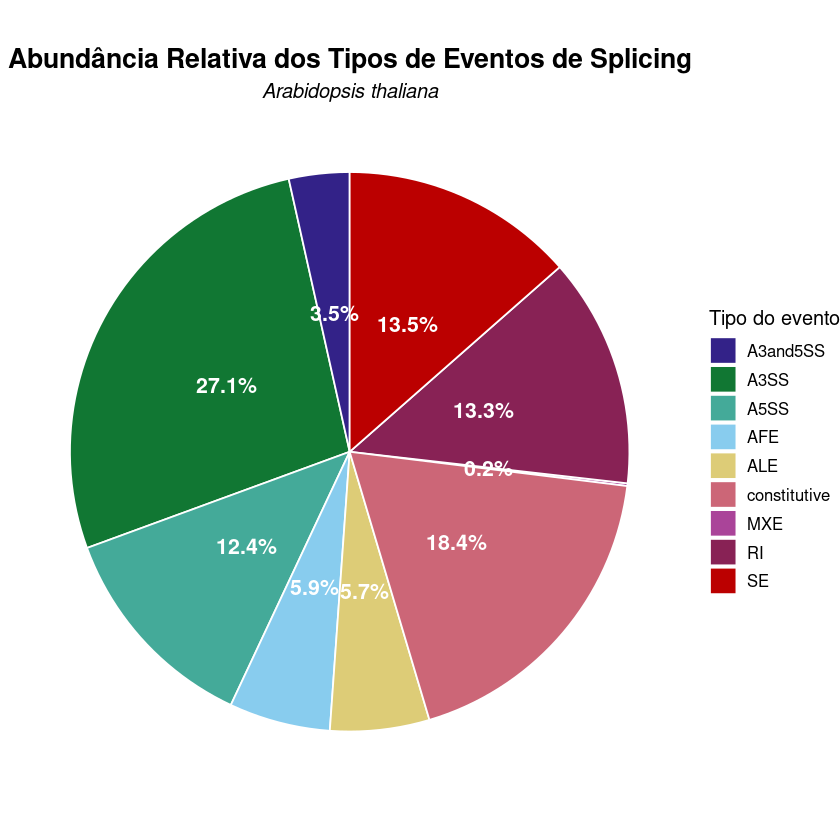

In [6]:
title = "Abundância Relativa dos Tipos de Eventos de Splicing"
subtitle = species

#title = "Relative Abundance of Splicing Event Types"
#subtitle = species

# Plotting the data - Pie chart

pie_chart <- ggplot(event_summary, aes(x = "", y = percentage, fill = event_type)) +
  geom_bar(stat = "identity", width = 2, color = "white") +
  coord_polar("y", start = 0) +
  geom_text(aes(label = paste0(round(percentage, 1), "%")),
            position = position_stack(vjust = 0.5),
            color = "white", size = 4.5, fontface = "bold") +

  # Formatting
  labs(title = title,
       subtitle = subtitle, 
       fill = "Tipo do evento") +
  theme_void() +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12,face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 10)) +
   scale_fill_manual(values = event_color_palette) 

pie_chart



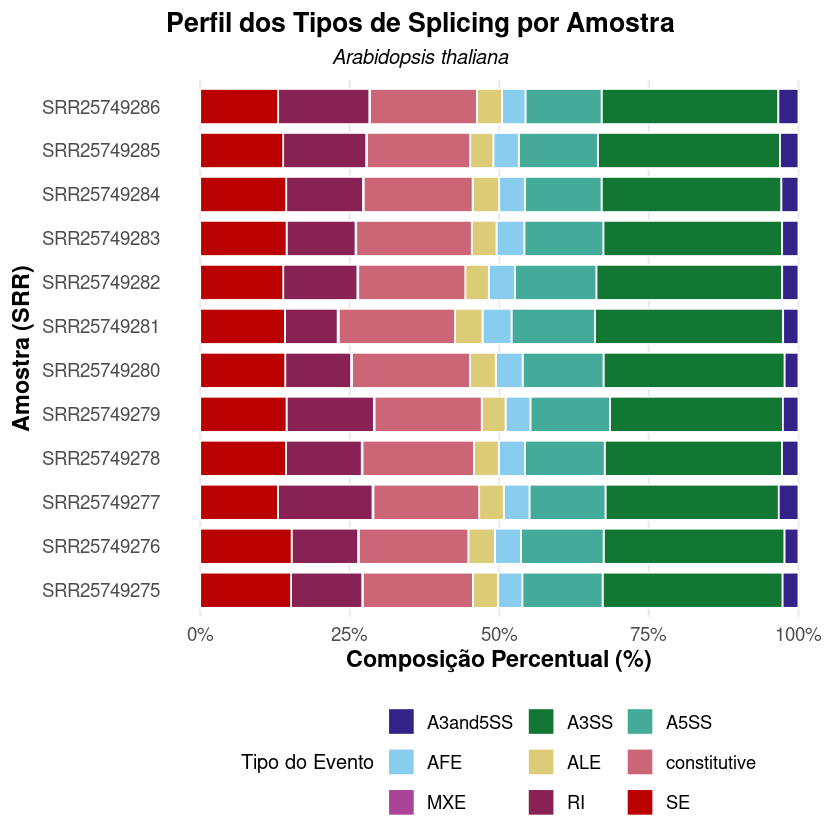

In [7]:
title = "Splicing Types Profile Across Samples"
subtitle = species
x = "Sample (SRR)"
y = "Percentage Composition (%)"
legend_title = "Splicing Type"

title = "Perfil dos Tipos de Splicing por Amostra"
subtitle = species
x = "Amostra (SRR)"
y = "Composição Percentual (%)"
legend_title = "Tipo do Evento"

# Plotting the data - Stacked bar chart
stacked_bar_chart = ggplot(event_sumarry_srr, aes(x = sra_id, y = percentage, fill = event_type)) +
  geom_col(position = "fill",width = 0.8, color = "white") +
  coord_flip() +
  scale_y_continuous(labels = scales::percent_format()) +
  guides(fill = guide_legend(nrow = 3, byrow = TRUE)) +
  
  # Formatting
  labs(title = title,
       subtitle = subtitle,
       x = x,
       y = y,
       fill = legend_title) +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11),
        axis.title = element_text(face = "bold", size = 14),
        legend.position = "bottom", 
        plot.title.position = "plot",
        plot.caption.position = "plot",
        panel.grid.major.y = element_blank(),
        panel.grid.minor.x = element_blank(),) +
  scale_fill_manual(values = event_color_palette)

stacked_bar_chart

ggsave(stacked_bar_chart, filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/perfil_tipos_por_amostra_Sbicolor.svg", width = 10, height = 6)

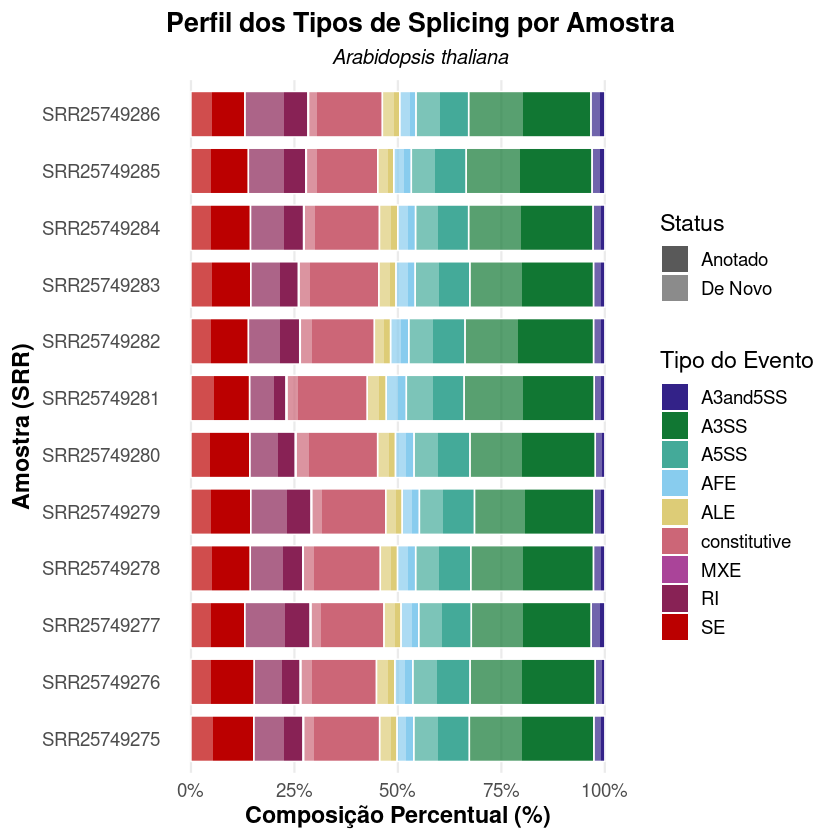

In [8]:

title = "Splicing Types Profile Across Samples"
subtitle = species
x = "Sample (SRR)"
y = "Percentage Composition (%)"
legend_title = "Splicing Type"
legend_title2 = "Status"

title = "Perfil dos Tipos de Splicing por Amostra"
subtitle = species
x = "Amostra (SRR)"
y = "Composição Percentual (%)"
legend_title = "Tipo do Evento"
legend_title2 = "Status"

# Plotting the data - Stacked bar chart
stacked_bar_chart_de_novo = ggplot() + 
    geom_col(data = event_sumarry_srr_denovo, 
             aes(x = sra_id, y = percentage, fill = event_type, alpha = status_label), 
             position = "fill", width = 0.8) +
    geom_col(data = event_sumarry_srr,
             aes(x = sra_id, y = count, group = event_type), 
             position = "fill", width = 0.8, color = "#ffffff", 
             alpha = 0.5, fill = NA, linewidth = 0.4) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +

    # Formatting
    labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y,
    fill = legend_title,
    alpha = legend_title2

    ) +

    theme_minimal(base_size = 14) +
    theme(
        panel.grid.major.y = element_blank(),
        panel.grid.minor.x = element_blank(),
        axis.title = element_text(face = "bold"),
        plot.title.position = "plot",
        plot.caption.position = "plot",
        plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
        plot.subtitle = element_text(hjust = 0.5, face = "italic", size = 12),
        legend.position = "right"
    ) +

    scale_alpha_manual(values = c("Anotado" = 1.0, "De Novo" = 0.7)) +
    scale_fill_manual(values = event_color_palette)

stacked_bar_chart_de_novo

ggsave(stacked_bar_chart_de_novo, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/perfil_tipos_por_amostra_de_novo_Sbicolor.svg", 
       width = 10, height = 6)

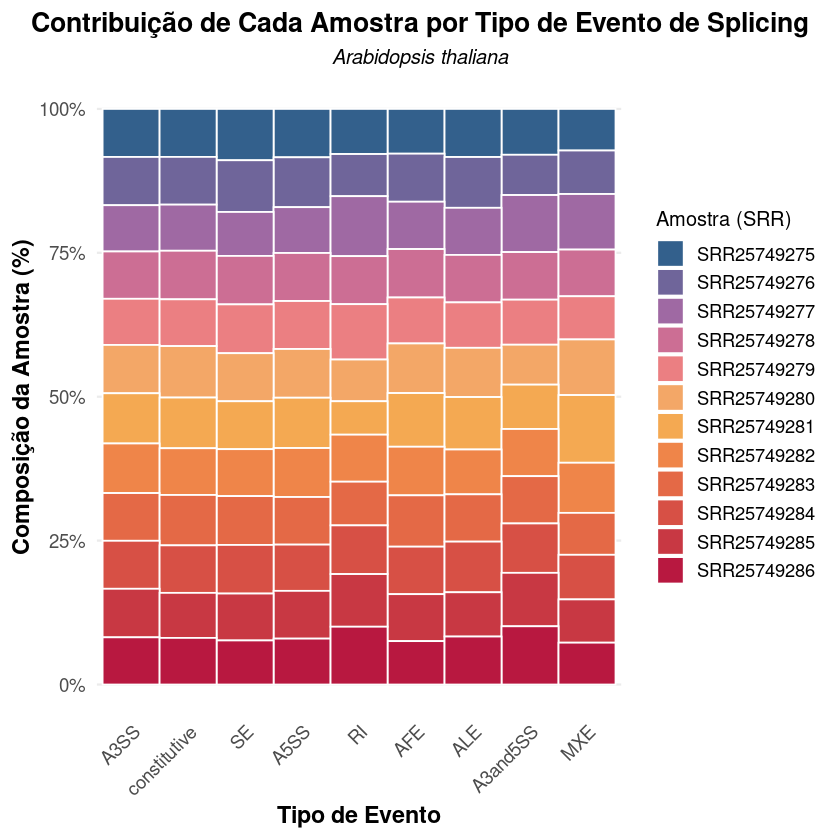

In [9]:

title = "Sample Contribution to Each Splicing Event Type"
subtitle = species
y = "Sample Composition (%)"
x = "Event Type"
legend_title = "Sample (SRR)"

title = "Contribuição de Cada Amostra por Tipo de Evento de Splicing"
subtitle = species
y = "Composição da Amostra (%)"
x = "Tipo de Evento"
legend_title = "Amostra (SRR)"

# Plotting the data - Stacked bar chart
composition_chart <- ggplot(event_sumarry_srr, aes(x = reorder(event_type, -count), y = percentage, fill = sra_id)) +
  geom_col(position = "fill", width = 1, color = "white") +
  scale_y_continuous(labels = scales::percent_format()) +
  
  # Formatting
  labs(title = title,
       subtitle = subtitle,
       x = x,
       y = y,
       fill = legend_title) +

  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11),
        axis.title = element_text(face = "bold", size = 14),
        plot.title.position = "plot",
        plot.caption.position = "plot",
        axis.text.x = element_text(angle = 45, hjust = 1),
        panel.grid.major.x = element_blank(),
        panel.grid.minor.y = element_blank(),
        ) +
  scale_fill_manual(values = paletteer_c("ggthemes::Sunset-Sunrise Diverging", n = length(unique(event_sumarry_srr$sra_id))))

composition_chart

### Comparing datasets

In [60]:
atha_event_summary <- athaliana_splicing_events %>%
    count(event_type, name = "count") %>%
    mutate(percentage = count / sum(count) * 100) 

zeam_event_summary <- zeamays_splicing_events %>%
    count(event_type, name = "count") %>%
    mutate(percentage = count / sum(count) * 100)

sor_event_summary <- sorghumbicolor_splicing_events %>%
    count(event_type, name = "count") %>%
    mutate(percentage = count / sum(count) * 100)

ory_event_summary <- oryzasativa_splicing_events %>%
    count(event_type, name = "count") %>%
    mutate(percentage = count / sum(count) * 100)

# Combine all event summaries into a single data frame
combined_event_summary_2 <- bind_rows(
    atha_event_summary %>% mutate(species = "Arabidopsis thaliana"),
    zeam_event_summary %>% mutate(species = "Zea mays"),
    sor_event_summary %>% mutate(species = "Sorghum bicolor"),
    ory_event_summary %>% mutate(species = "Oryza sativa")
)

combined_event_summary_2

eventos_filtrados <- combined_event_summary_2 %>%
  filter(event_type %in% c("SE", "RI", "A3SS", "A5SS"))

event_type,count,percentage,species
<chr>,<int>,<dbl>,<chr>
A3SS,12993,30.9703716,Arabidopsis thaliana
A3and5SS,389,0.9272281,Arabidopsis thaliana
A5SS,6840,16.3039592,Arabidopsis thaliana
AFE,2071,4.9364765,Arabidopsis thaliana
ALE,1295,3.0867876,Arabidopsis thaliana
MXE,54,0.1287155,Arabidopsis thaliana
RI,2074,4.9436274,Arabidopsis thaliana
SE,3603,8.5881820,Arabidopsis thaliana
constitutive,12634,30.1146521,Arabidopsis thaliana


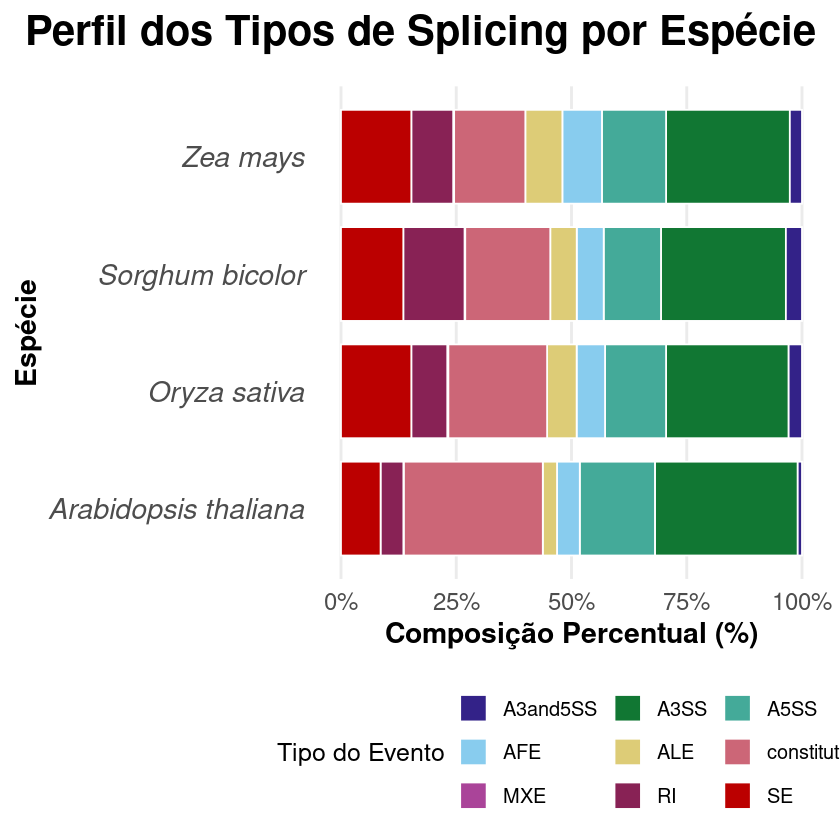

In [62]:
title = "Splicing Types Profile Across Species"
subtitle = ""
x = "Spicies"
y = "Percentage Composition (%)"
legend_title = "Splicing Type"

title = "Perfil dos Tipos de Splicing por Espécie"
subtitle = ""
x = "Espécie"
y = "Composição Percentual (%)"
legend_title = "Tipo do Evento"

# Plotting the data - Stacked bar chart
stacked_bar_chart_all = ggplot(combined_event_summary_2, aes(x = species, y = percentage, fill = event_type)) +
  geom_col(position = "fill",width = 0.8, color = "white") +
  coord_flip() +
  scale_y_continuous(labels = scales::percent_format()) +
  guides(fill = guide_legend(nrow = 3, byrow = TRUE)) +
  
  # Formatting
  labs(title = title,
       subtitle = subtitle,
       x = x,
       y = y,
       fill = legend_title) +
  theme_minimal(base_size = 18) +
  theme(plot.title = element_text(hjust = 0.5, size = 25, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 1, face = "italic"),
        legend.title = element_text(size = 15),
        legend.text = element_text(size = 12),
        axis.title = element_text(face = "bold", size = 17),
        legend.position = "bottom", 
        plot.title.position = "plot",
        plot.caption.position = "plot",
        panel.grid.major.y = element_blank(),
        panel.grid.minor.x = element_blank(),
        axis.text.y = element_text(face = "italic", size = 17)) +
  scale_fill_manual(values = event_color_palette)

stacked_bar_chart_all

ggsave(stacked_bar_chart_all, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/perfil_tipos_por_especies.svg", 
       width = 10, height = 6)

In [64]:
athaliana_event_summary <- athaliana_splicing_events %>%
    count(event_type, name = "count") %>%
    mutate(percentage = count / sum(count) * 100)

zmays_event_summary <- zeamays_splicing_events %>%
    count(event_type, name = "count") %>%
    mutate(percentage = count / sum(count) * 100)

osativa_event_summary <- oryzasativa_splicing_events %>%
    count(event_type, name = "count") %>%
    mutate(percentage = count / sum(count) * 100)

sbicolor_event_summary <- sorghumbicolor_splicing_events %>%
    count(event_type, name = "count") %>%
    mutate(percentage = count / sum(count) * 100)

# Combine all event summaries into a single data frame
all_event_summary <- bind_rows(
    athaliana_event_summary %>% mutate(species = "Arabidopsis thaliana"),
    zmays_event_summary %>% mutate(species = "Zea mays"),
    osativa_event_summary %>% mutate(species = "Oryza sativa"),
    sbicolor_event_summary %>% mutate(species = "Sorghum bicolor")
)

all_event_summary
all_event_summary <- all_event_summary %>%
  mutate(event_type = fct_reorder(event_type, percentage, .fun = "mean", .desc = TRUE))

event_type,count,percentage,species
<chr>,<int>,<dbl>,<chr>
A3SS,12993,30.9703716,Arabidopsis thaliana
A3and5SS,389,0.9272281,Arabidopsis thaliana
A5SS,6840,16.3039592,Arabidopsis thaliana
AFE,2071,4.9364765,Arabidopsis thaliana
ALE,1295,3.0867876,Arabidopsis thaliana
MXE,54,0.1287155,Arabidopsis thaliana
RI,2074,4.9436274,Arabidopsis thaliana
SE,3603,8.5881820,Arabidopsis thaliana
constitutive,12634,30.1146521,Arabidopsis thaliana


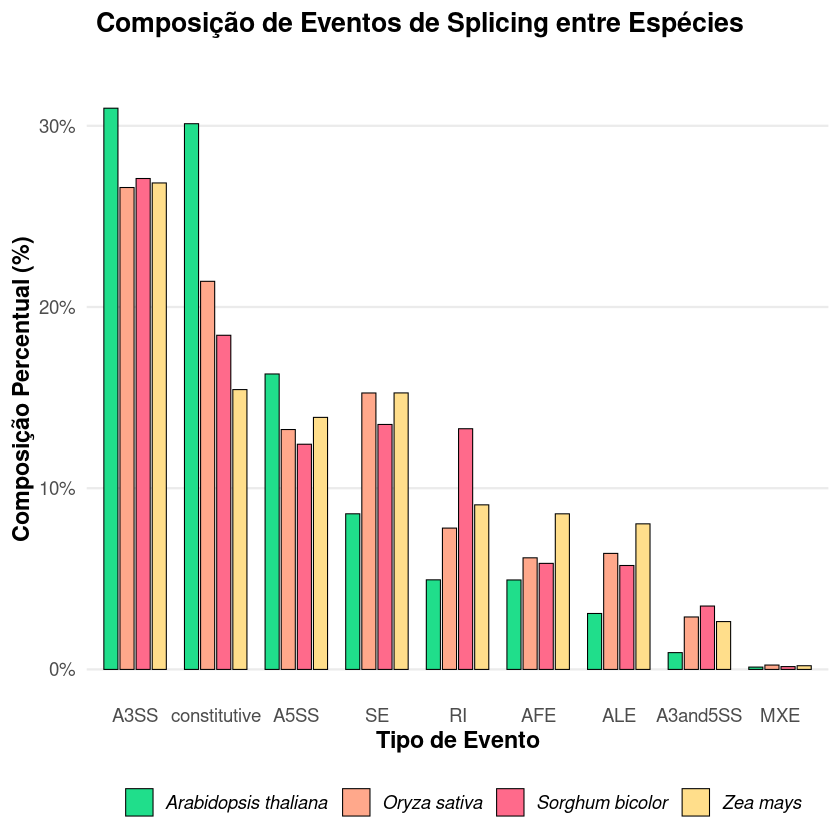

In [62]:
title = "Comparison of Splicing Event Composition Across Species"
subtitle = ""
y = "Percentage Composition (%)"
x = "Event Type"
legend_title = ""


title = "Composição de Eventos de Splicing entre Espécies"
subtitle = ""
y = "Composição Percentual (%)"
x = "Tipo de Evento"
legend_title = ""


# Plotting the data - Comparative Bar Chart
comparative_bar_chart <- ggplot(data = all_event_summary, aes(x = event_type, y = percentage, fill=species)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7, 
          color = "black", linewidth = 0.3) + 
scale_y_continuous(labels = function(x) paste0(x, "%")) +

  # Formatting
  labs(title = title,
       subtitle = subtitle,
       x = x,
       y = y,
       fill = legend_title) +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11, face = "italic"),
        axis.title = element_text(face = "bold", size = 14),
        plot.title.position = "plot",
        plot.caption.position = "plot",
        panel.grid.major.x = element_blank(),
        panel.grid.minor.y = element_blank(),
        legend.position = "bottom") +
     scale_fill_manual(values = species_color_palette) 

comparative_bar_chart

ggsave(comparative_bar_chart, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/composicao_eventos_splicing_entre_especies.svg", 
       width = 10, height = 6)

In [65]:
dados_publicados <- tribble(
  ~species,          ~event_type, ~percentage,
  "Human - HG18",    "INT",      10.8,
  "Human - HG18",    "EX",       51.4,
  "Human - HG18",    "ALTA",     11.2,
  "Human - HG18",    "ALTD",     7.6,
  "Human - HG38",    "INT",      12.5,
  "Human - HG38",    "EX",       30.4,
  "Human - HG38",    "ALTA",     7.1,
  "Human - HG38",    "ALTD",     4.2,
  "Arabidopsis thaliana (Ref.)",     "INT",      29.6,
  "Arabidopsis thaliana (Ref.)",     "EX",       23.9,
  "Arabidopsis thaliana (Ref.)",     "ALTA",     30.0,
  "Arabidopsis thaliana (Ref.)",     "ALTD",     16.5
) %>%
  mutate(event_type = recode(event_type,
                            "INT" = "RI",
                            "EX" = "SE",
                            "ALTA" = "A3SS",
                            "ALTD" = "A5SS")) %>%
  select(species, event_type, percentage)

all_event_summary_plus_literature <- bind_rows(all_event_summary, dados_publicados) %>%
    filter(!event_type %in% c("AFE", "ALE", "MXE", "A3and5SS", "constitutive")) %>%
    mutate(event_type = fct_reorder(event_type, percentage, .fun = "mean", .desc = TRUE))
all_event_summary_plus_literature

event_type,count,percentage,species
<fct>,<int>,<dbl>,<chr>
A3SS,12993,30.970372,Arabidopsis thaliana
A5SS,6840,16.303959,Arabidopsis thaliana
RI,2074,4.943627,Arabidopsis thaliana
SE,3603,8.588182,Arabidopsis thaliana
A3SS,21079,26.845390,Zea mays
A5SS,10921,13.908558,Zea mays
RI,7131,9.081763,Zea mays
SE,11981,15.258533,Zea mays
A3SS,26931,26.593528,Oryza sativa


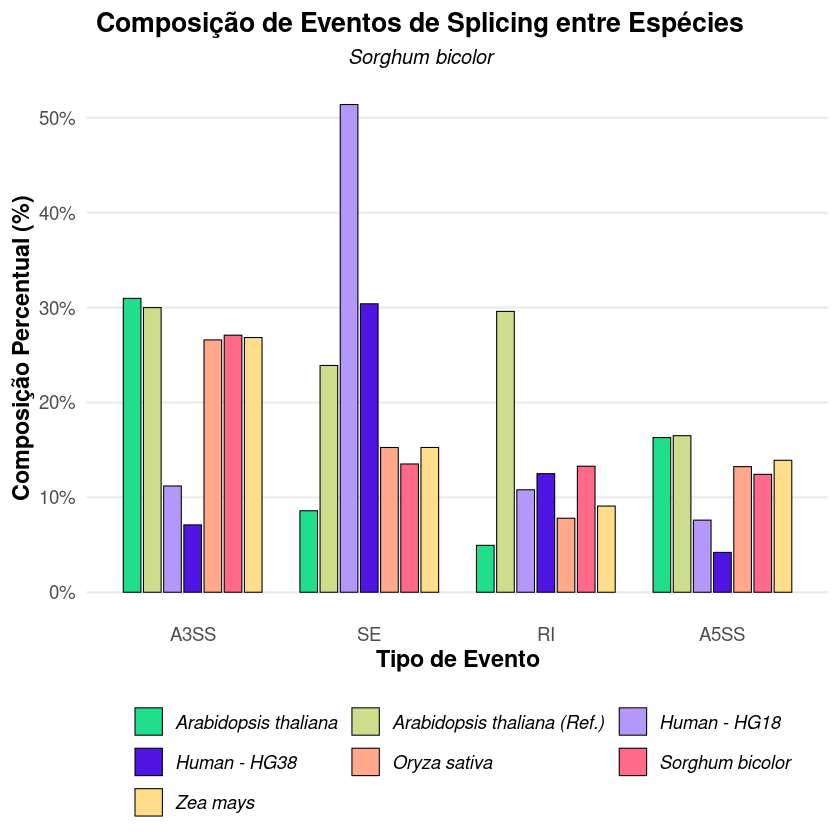

In [68]:
title = "Comparison of Splicing Event Composition Across Species"
subtitle = species
y = "Percentage Composition (%)"
x = "Event Type"
legend_title = ""

title = "Composição de Eventos de Splicing entre Espécies"
subtitle = species
y = "Composição Percentual (%)"
x = "Tipo de Evento"
legend_title = ""


# Plotting the data - Comparative Bar Chart
comparative_bar_chart_literature <- ggplot(data = all_event_summary_plus_literature, aes(x = event_type, y = percentage, fill=species)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7, 
          color = "black", linewidth = 0.3) + 
  scale_y_continuous(labels = function(x) paste0(x, "%")) +
     guides(
     fill = guide_legend(nrow = 3, byrow = TRUE),
    ) + 

  # Formatting
  labs(title = title,
       subtitle = subtitle,
       x = x,
       y = y,
       fill = legend_title) +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11, face = "italic"),
        axis.title = element_text(face = "bold", size = 14),
        plot.title.position = "plot",
        plot.caption.position = "plot",
        panel.grid.major.x = element_blank(),
        panel.grid.minor.y = element_blank(),
        legend.position = "bottom") +
     scale_fill_manual(values = species_color_palette)

comparative_bar_chart_literature

ggsave(comparative_bar_chart_literature, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/composicao_eventos_splicing_entre_especies_literatura.png", 
       width = 10, height = 6)

species,event_type,percentage
<chr>,<chr>,<dbl>
Human - HG18,RI,10.8
Human - HG18,SE,51.4
Human - HG18,A3SS,11.2
Human - HG18,A5SS,7.6
Human - HG38,RI,12.5
Human - HG38,SE,30.4
Human - HG38,A3SS,7.1
Human - HG38,A5SS,4.2
Arabidopsis thaliana (Ref.),RI,31.4


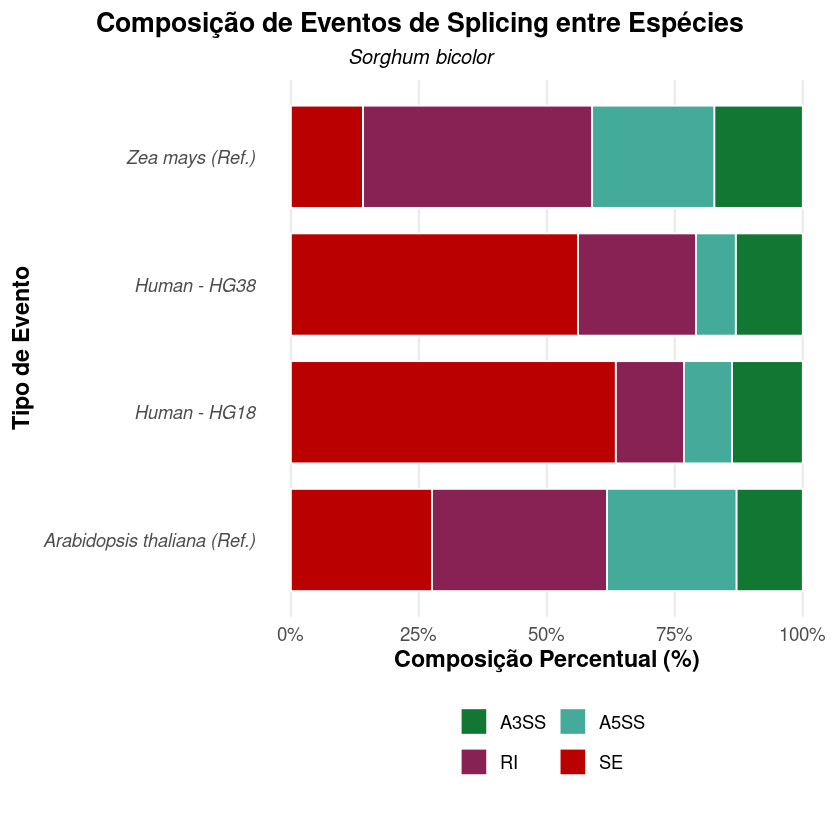

In [72]:

dados_publicados <- tribble(
  ~species,                       ~event_type, ~percentage,
  "Human - HG18",                 "INT",       10.8,
  "Human - HG18",                 "EX",        51.4,
  "Human - HG18",                 "ALTA",      11.2,
  "Human - HG18",                 "ALTD",      7.6,
  "Human - HG38",                 "INT",       12.5,
  "Human - HG38",                 "EX",        30.4,
  "Human - HG38",                 "ALTA",      7.1,
  "Human - HG38",                 "ALTD",      4.2,
  "Arabidopsis thaliana (Ref.)",  "INT",       31.4,
  "Arabidopsis thaliana (Ref.)",  "EX",        25.3,
  "Arabidopsis thaliana (Ref.)",  "ALTA",      11.9,
  "Arabidopsis thaliana (Ref.)",  "ALTD",      23.2,
  "Zea mays (Ref.)",              "INT",       43.0,
  "Zea mays (Ref.)",              "EX",        13.5,
  "Zea mays (Ref.)",              "ALTA",      16.6,
  "Zea mays (Ref.)",              "ALTD",      22.9
)%>%
  mutate(event_type = recode(event_type,
                            "INT" = "RI",
                            "EX" = "SE",
                            "ALTA" = "A3SS",
                            "ALTD" = "A5SS",
                            "CS" = "constitutive")) %>%
  select(species, event_type, percentage)

dados_publicados

# Aplique o mapa para padronizar os nomes e prepare para o gráfico
dados_publicados_preparado <- ggplot(dados_publicados, aes(x = species, y = percentage, fill = event_type)) +
  geom_col(position = "fill",width = 0.8, color = "white") +
  coord_flip() +
  scale_y_continuous(labels = scales::percent_format()) +
  guides(fill = guide_legend(nrow = 3, byrow = TRUE)) +
  
  # Formatting
  labs(title = title,
       subtitle = subtitle,
       x = x,
       y = y,
       fill = legend_title) +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11),
        axis.title = element_text(face = "bold", size = 14),
        legend.position = "bottom", 
        plot.title.position = "plot",
        plot.caption.position = "plot",
        panel.grid.major.y = element_blank(),
        panel.grid.minor.x = element_blank(),
        axis.text.y = element_text(face = "italic", size = 11)) +
  scale_fill_manual(values = event_color_palette)

# Exibe o gráfico
print(dados_publicados_preparado)
ggsave(dados_publicados_preparado, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/composicao_eventos_splicing_entre_especies_literatura_2.png", 
       width = 10, height = 6)

### Splicing types tendency

📎 Event discovery trend by splicing type

❓ Is there any event that has been added more frequently?

Curva de Acumulação (ou Rarefação)

In [49]:
full_events_df <- sample_info_df %>%
  left_join(splicing_events_df %>% select(event_id, event_type), by = "event_id") %>%
  filter(!is.na(event_type), !is.na(sra_id))

all_samples <- unique(full_events_df$sra_id)
num_samples <- length(all_samples)
n_permutations <- 50

head(full_events_df)
all_samples
num_samples

id,event_id,de_novo,mean_psi_majiq,psi_sgseq,sra_id,majiq,sgseq,species,event_type
<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<int>,<int>,<chr>,<chr>
668146,"LOC_Os04g13600_Chr4:7596026,7596126-7596211,7596490_-_A5SS",True,0.83540,0,ERR11809331,1,0,Oryza sativa,A5SS
668147,"LOC_Os04g13600_Chr4:7596026,7596126-7596232,7596490_-_A5SS",True,0.16460,0,ERR11809331,1,0,Oryza sativa,A5SS
668148,"LOC_Os12g34870_Chr12:21227049,21227181-21227262,21227311_-_A5SS",False,0.69050,0,ERR11809331,1,0,Oryza sativa,A5SS
668149,"LOC_Os12g34870_Chr12:21227049,21227181-21227281,21227311_-_A5SS",False,0.30950,0,ERR11809331,1,0,Oryza sativa,A5SS
668150,"LOC_Os04g14510_Chr4:8119097,8119167-8119240,8119492_-_A5SS",False,0.91360,0,ERR11809331,1,0,Oryza sativa,A5SS
668151,"LOC_Os04g14510_Chr4:8119097,8119167-8119261,8119492_-_A5SS",True,0.08643,0,ERR11809331,1,0,Oryza sativa,A5SS


[1] "ERR11809331" "ERR11809330" "ERR11809329" "ERR11809328" "ERR11809327"
 [6] "ERR11809326" "ERR11809325" "ERR11809324" "ERR11809323" "ERR11809322"
[11] "ERR11809321" "ERR11809320" "ERR11809319" "ERR11809318" "ERR11809317"
[16] "ERR11809316" "ERR11809315" "ERR11809314" "ERR11809313" "ERR11809312"

[1] 20

In [50]:
accumulation_results_all_types <- data.frame()

for (i in 1:n_permutations) {
  shuffled_samples <- sample(all_samples, num_samples, replace = FALSE)
  for (k in 1:num_samples) {
    current_samples <- shuffled_samples[1:k]
    temp_counts <- full_events_df %>%
      filter(sra_id %in% current_samples) %>%
      group_by(event_type) %>%
      summarise(unique_events = n_distinct(event_id), .groups = 'drop')
    temp_counts$permutation <- i
    temp_counts$samples_added <- k
    accumulation_results_all_types <- rbind(accumulation_results_all_types, temp_counts)
  }
}

summary_cumulative <- accumulation_results_all_types %>%
  group_by(event_type, samples_added) %>%
  summarise(
    mean_unique_events = mean(unique_events),
    sd_unique_events = sd(unique_events),
    .groups = 'drop'
  )

  derivative_data <- accumulation_results_all_types %>%
  group_by(permutation, event_type) %>%
  arrange(samples_added, .by_group = TRUE) %>%
  mutate(newly_discovered = unique_events - lag(unique_events, default = 0)) %>%
  ungroup()

summary_derivative <- derivative_data %>%
  group_by(event_type, samples_added) %>%
  summarise(mean_new_events = mean(newly_discovered), .groups = 'drop')



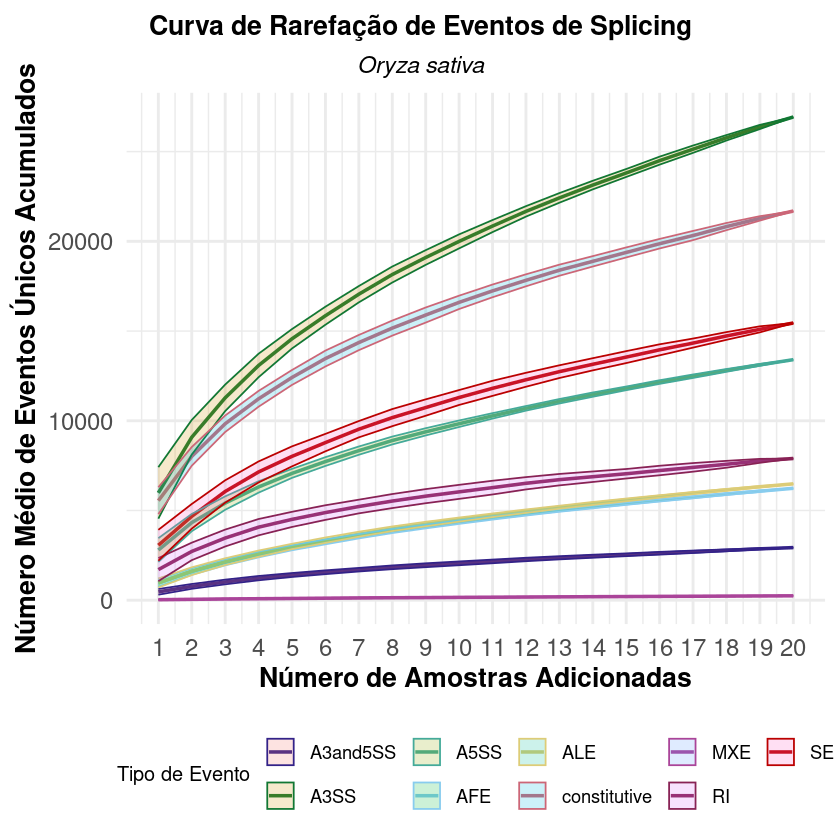

In [51]:
title = "Splicing Event Rarefaction Curve"
subtitle = species
y = "Mean Number of Cumulative Unique Events"
x = "Number of Samples Added"
legend_title = "Event Type"

title = "Curva de Rarefação de Eventos de Splicing"
subtitle = species
y = "Número Médio de Eventos Únicos Acumulados"
x = "Número de Amostras Adicionadas"
legend_title = "Tipo de Evento"

# Plotting the data - Cumulative Rarefaction Curve
rarefaction_plot <- ggplot(summary_cumulative, aes(x = samples_added, y = mean_unique_events, color = event_type, fill = event_type)) +
  geom_line(linewidth = 1) +
  geom_ribbon(aes(ymin = mean_unique_events - sd_unique_events, ymax = mean_unique_events + sd_unique_events), alpha = 0.2) +
  scale_x_continuous(breaks = 1:num_samples) +

  # Formatting
  labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y,
    color = legend_title,
    fill = legend_title
  ) +
  theme_minimal(base_size = 18) +
  theme(legend.position = "bottom",
        plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 14, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11),
        axis.title = element_text(face = "bold", size = 16),
        plot.title.position = "plot",
        plot.caption.position = "plot"
  ) +
    scale_color_manual(values = event_color_palette)

  rarefaction_plot

ggsave(rarefaction_plot, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/curva_rarefacao_eventos_splicing_osativa.png", 
       width = 10, height = 10)

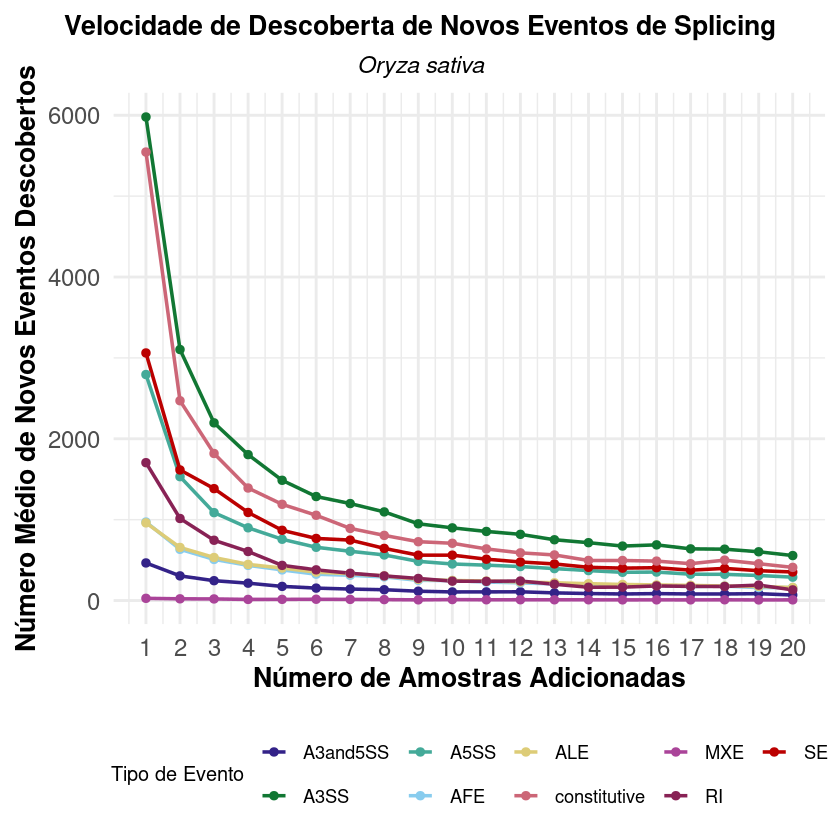

In [52]:
title = "Discovery Rate of New Splicing Events"
subtitle = species
y = "Mean Number of New Events Discovered"
x = "Number of Samples Added"
legend_title = "Event Type"

title = "Velocidade de Descoberta de Novos Eventos de Splicing"
subtitle = species
y = "Número Médio de Novos Eventos Descobertos"
x = "Número de Amostras Adicionadas"
legend_title = "Tipo de Evento"

# Plotting the data - Derivative of Rarefaction Curve
derivative_plot <- ggplot(summary_derivative, aes(x = samples_added, y = mean_new_events, color = event_type)) +
  geom_line(linewidth = 1) +
  geom_point(size=2) +
  scale_x_continuous(breaks = 1:num_samples) +

  # Formatting
  labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y,
    color = legend_title
  ) +
  theme_minimal(base_size = 18) +
  theme(legend.position = "bottom",
        plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 14, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11),
        axis.title = element_text(face = "bold", size = 16),
        plot.title.position = "plot",
        plot.caption.position = "plot"
  ) +
  scale_color_manual(values = event_color_palette)
  
derivative_plot

ggsave(derivative_plot, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/velocidade_descoberta_novos_eventos_splicing_osativa.png", 
       width = 10, height = 10)

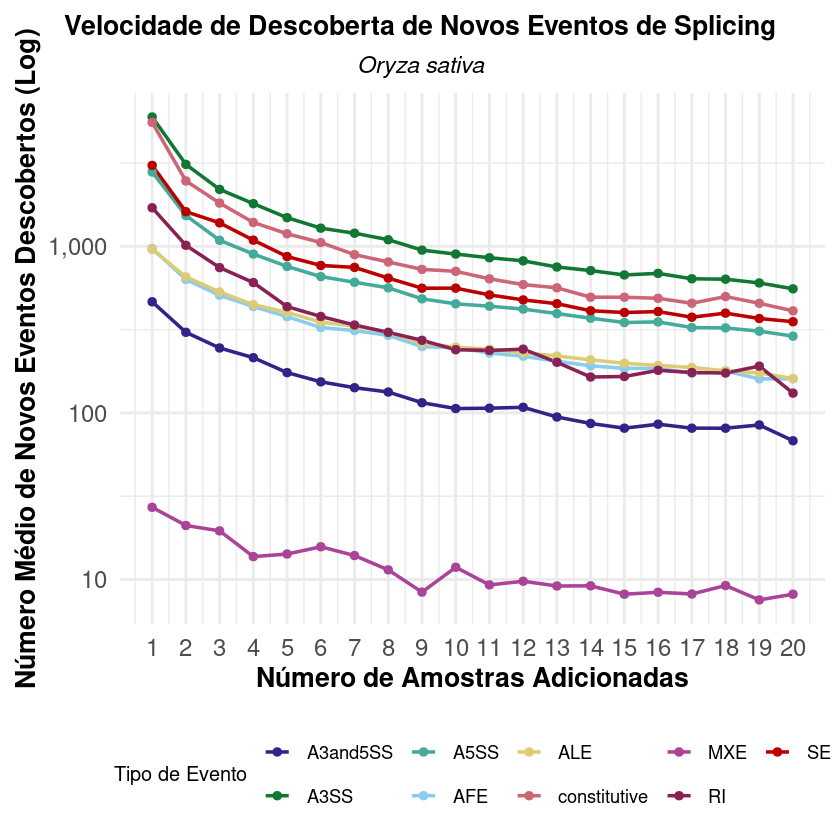

In [53]:
title = "Discovery Rate of New Splicing Events"
subtitle = species
y = "Mean Number of New Events Discovered (Log)"
x = "Number of Samples Added"
legend_title = "Event Type"

title = "Velocidade de Descoberta de Novos Eventos de Splicing"
subtitle = species
y = "Número Médio de Novos Eventos Descobertos (Log)"
x = "Número de Amostras Adicionadas"
legend_title = "Tipo de Evento"

# Plotting the data - Derivative of Rarefaction Curve (Log Scale)
derivative_plot_log <- ggplot(summary_derivative, aes(x = samples_added, y = mean_new_events, color = event_type)) +
  geom_line(linewidth = 1) +
  geom_point(size=2) +
  scale_x_continuous(breaks = 1:num_samples) +
  scale_y_log10(labels = scales::comma) + #

  # Formatting
  labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y,
    color = legend_title
  ) +
  theme_minimal(base_size = 18) +
  theme(legend.position = "bottom",
        plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 14, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11),
        axis.title = element_text(face = "bold", size = 16),
        plot.title.position = "plot",
        plot.caption.position = "plot"
  ) + 
  scale_color_manual(values = event_color_palette)
  
derivative_plot_log

ggsave(derivative_plot_log, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/velocidade_descoberta_novos_eventos_splicing_log_osativa.png", 
       width = 10, height = 10)

### Average event per gene
📎 Visão geral do número médio de eventos de splicing por gene.

❓ Quantos eventos de splicing diferentes ocorrem, em média, para cada gene? Esse número varia entre as espécies?

In [77]:
events_per_gene <- splicing_events_df %>%
  group_by(gene_name, event_type) %>%
  summarise(count = n(), .groups = 'drop')

mean_counts <- events_per_gene %>%
  group_by(event_type) %>%
  summarise(mean_count = mean(count), .groups = 'drop')

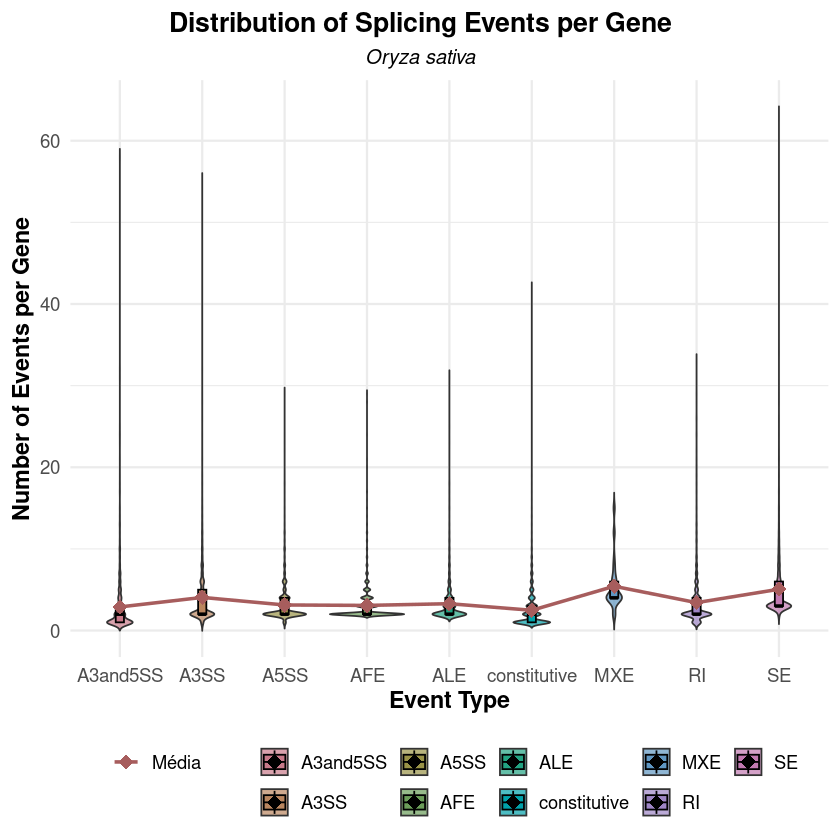

In [157]:
title = "Distribuição de Eventos de Splicing por Gene"
subtitle = species
y = "Número de Eventos por Gene"
x = "Tipo de Evento"
legend_title = ""

title = "Distribution of Splicing Events per Gene"
subtitle = species
y = "Number of Events per Gene"
x = "Event Type"

# Plotting the data - Derivative of Rarefaction Curve 
violin_plot_events_per_gene_ = ggplot(events_per_gene, aes(x = event_type, y = count, fill = event_type)) +
  geom_violin(trim = FALSE, alpha = 0.7) +
  geom_boxplot(width = 0.1, color = "black", outlier.shape = NA, coef = 0) +
  geom_line(data = mean_counts, aes(y = mean_count, group = 1, color = "Média"), linewidth = 1) +
  geom_point(data = mean_counts, aes(y = mean_count, color = "Média"), shape = 18, size = 4) +

  # Formatting
  labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y,
    fill = legend_title
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "bottom",
        plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11),
        axis.title = element_text(face = "bold", size = 14),
        plot.title.position = "plot",
        plot.caption.position = "plot"
  ) +
  scale_fill_manual(values = event_color_palette) +
  scale_color_manual(name = "", values = c("Média" = "#a75d5d")) 

violin_plot_events_per_gene_

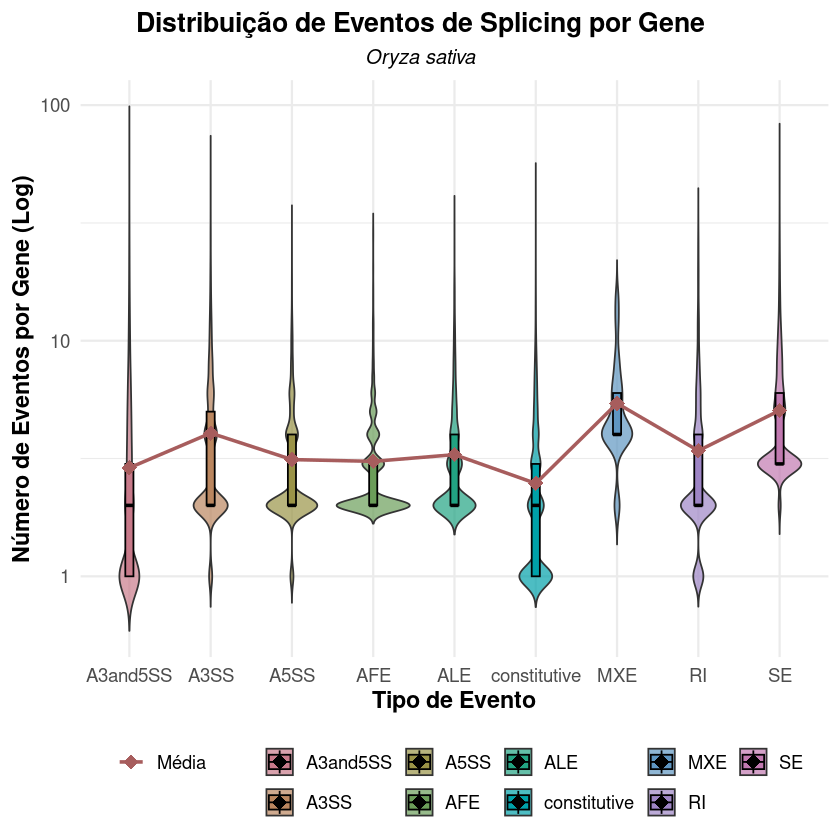

In [158]:
title = "Distribution of Splicing Events per Gene"
subtitle = species
y = "Number of Events per Gene (Log)"
x = "Event Type"

title = "Distribuição de Eventos de Splicing por Gene"
subtitle = species
y = "Número de Eventos por Gene (Log)"
x = "Tipo de Evento"
legend_title = ""

# Plotting the data - Derivative of Rarefaction Curve (Log Scale)
violin_plot_events_per_gene = ggplot(events_per_gene, aes(x = event_type, y = count, fill = event_type)) +
  geom_violin(trim = FALSE, alpha = 0.7) +
  geom_boxplot(width = 0.1, color = "black", outlier.shape = NA, coef = 0) +
  geom_line(data = mean_counts, aes(y = mean_count, group = 1, color = "Média"), linewidth = 1) +
  geom_point(data = mean_counts, aes(y = mean_count, color = "Média"), shape = 18, size = 4) +
  scale_y_log10(labels = scales::comma) + 

  # Formatting
  labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y,
    fill = legend_title
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "bottom",
        plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11),
        axis.title = element_text(face = "bold", size = 14),
        plot.title.position = "plot",
        plot.caption.position = "plot"
  ) +
  scale_fill_manual(values = event_color_palette) +
  scale_color_manual(name = "", values = c("Média" = "#a75d5d")) 

violin_plot_events_per_gene

### Event length distribution

📎 Distribuição do comprimento (em pares de base) para cada tipo de evento de splicing.

❓ Existem tipos de eventos que são caracteristicamente mais longos ou mais curtos que outros? A distribuição de tamanhos é semelhante entre os diferentes tipos de splicing?

gráfico de densidade de cristas (ridgeline plot) 

In [78]:
event_length_summary <- splicing_events_df %>%
  mutate(event_length = end - start) %>%
  filter(event_length > 0)

Picking joint bandwidth of 0.0823



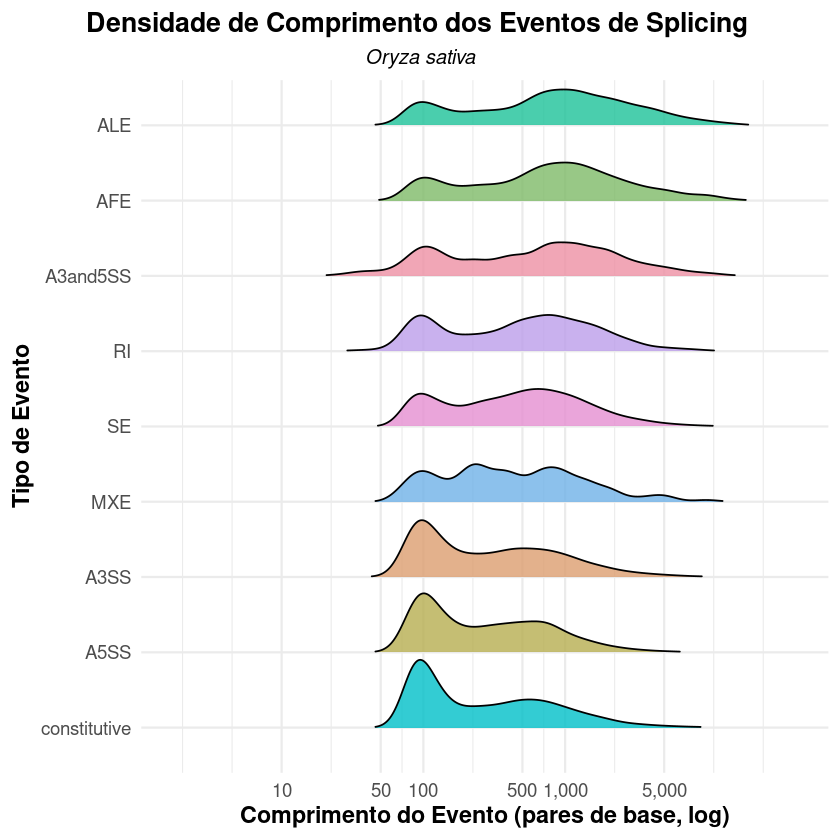

In [160]:
title = "Distribution of Splicing Event Lengths"
subtitle = species
y = "Event Type"
x = "Event Length (base pairs, log)"

title = "Densidade de Comprimento dos Eventos de Splicing "
subtitle = species
y = "Tipo de Evento"
x = "Comprimento do Evento (pares de base, log)"
legend_title = ""

# Plotting the data - Distribution of Event Lengths
ridgeline_plot <- ggplot(
    event_length_summary,
    aes(x = event_length, 
        y = reorder(event_type, event_length, FUN = median), 
        fill = event_type)) +

    geom_density_ridges(
        alpha = 0.8, 
        scale = 0.9, 
        rel_min_height = 0.01, 
        show.legend = FALSE) + 
    
    scale_x_log10(
    name = x,
    breaks = c(10, 50, 100, 500, 1000, 5000),
    labels = comma 
  ) +
  
  # Formatting
  labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y,
    fill = legend_title
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "bottom",
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
      legend.title = element_text(size = 12),
      legend.text = element_text(size = 11),
      axis.title = element_text(face = "bold", size = 14),
      plot.title.position = "plot",
      plot.caption.position = "plot"
) +
  scale_fill_manual(values = paletteer_c("grDevices::Set 2", n = 9)) 

ridgeline_plot

### De novo vs annotated
📎 Comparação da proporção de eventos de splicing novos (de novo), que não constam na anotação de referência, versus os eventos já conhecidos (anotados).

❓ Qual a porcentagem de eventos de splicing descobertos que são inéditos? Essa proporção de novidade varia entre os diferentes tipos de evento ou entre as amostras analisadas?

In [123]:
event_summary_anotado = sample_info_df %>%
    count(de_novo, name = "count") %>%
    mutate(percentage = count / sum(count) * 100,
    de_novo = if_else(de_novo == "True", "De Novo", "Anotado")) %>%
    mutate(sra_id = "all") 

de_novo_per_sra_id <- sample_info_df %>%
    count(sra_id, de_novo, name = "count") %>%
    group_by(sra_id) %>%
    mutate(percentage = count / sum(count) * 100) %>%
    ungroup() %>%
    mutate(de_novo = if_else(de_novo == "True", "De Novo", "Anotado"))

de_novo_per_sra_id <- bind_rows(de_novo_per_sra_id, event_summary_anotado)

# Ordena os sra_id com base na porcentagem de "De Novo", excluindo "all"
ordered_sra_ids <- de_novo_per_sra_id %>%
  filter(de_novo == "De Novo", sra_id != "all") %>%
  arrange(desc(percentage)) %>%
  pull(sra_id) %>%
  unique()

# Adiciona "all" no final
ordered_sra_ids <- c(ordered_sra_ids, "all")

# Aplica a ordem como fator
de_novo_per_sra_id <- de_novo_per_sra_id %>%
  mutate(sra_id = factor(sra_id, levels = ordered_sra_ids))
  
de_novo_per_evet_type <- sample_info_df %>%
    group_by(event_id) %>%
      summarise(
        final_status = if_else(any(de_novo == "False"), "Anotado", "De Novo"),
        .groups = "drop"
      ) %>%
    left_join(splicing_events_df %>% select(event_id, event_type), by = "event_id") %>%
    filter(!is.na(event_type)) %>%
    count(event_type, final_status, name = "count") %>%
    group_by(event_type) %>%
    mutate(percentage = count / sum(count) * 100) %>%
    ungroup() # %>%
    # mutate(de_novo = if_else(de_novo == "True", "De Novo", "Anotado"))

#ordered_event_types <- de_novo_per_evet_type %>%
#  filter(de_novo == "De Novo") %>%
#  arrange(desc(percentage)) %>%
#  pull(event_type)



event_summary_anotado
head(de_novo_per_sra_id)
de_novo_per_evet_type

de_novo,count,percentage,sra_id
<chr>,<int>,<dbl>,<chr>
Anotado,344624,81.92946,all
De Novo,76011,18.07054,all


sra_id,de_novo,count,percentage
<fct>,<chr>,<int>,<dbl>
SRR27051148,Anotado,30225,82.49406
SRR27051148,De Novo,6414,17.50594
SRR27051149,Anotado,27675,82.86176
SRR27051149,De Novo,5724,17.13824
SRR27051150,Anotado,27420,83.26501
SRR27051150,De Novo,5511,16.73499


event_type,final_status,count,percentage
<chr>,<chr>,<int>,<dbl>
A3SS,Anotado,8122,62.510583
A3SS,De Novo,4871,37.489417
A3and5SS,Anotado,108,27.763496
A3and5SS,De Novo,281,72.236504
A5SS,Anotado,4241,62.002924
A5SS,De Novo,2599,37.997076
AFE,Anotado,1361,65.717045
AFE,De Novo,710,34.282955
ALE,Anotado,629,48.571429


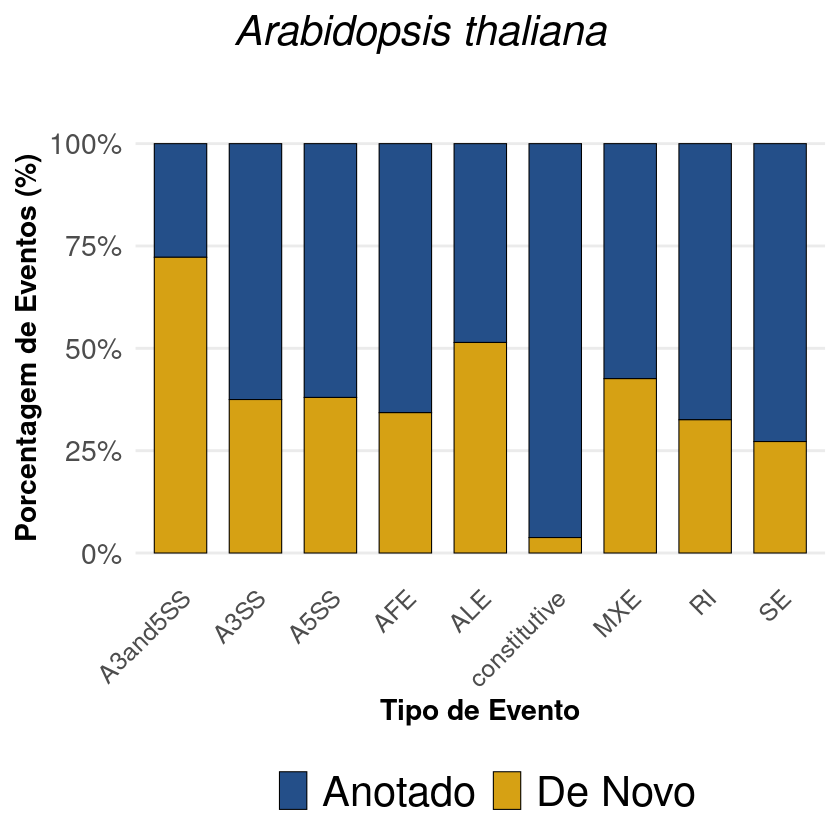

In [125]:

title = "Proportion of 'De Novo' Events by Splicing Type"
subtitle = ""
x = "Splicing Event Type"
y = "Percentage of Events (%)"
legend_title = ""

title = species
subtitle = ""
x = "Tipo de Evento"
y = "Porcentagem de Eventos (%)"
legend_title = ""

# Plotting the data - Bar plot per event type
denovo_event_type = ggplot(data =  de_novo_per_evet_type, aes(
    x = event_type, 
    y = count, 
    fill = final_status)) +
  geom_col(position = "fill", width = 0.7, color = "black", linewidth = 0.3) +
  scale_y_continuous(labels = percent_format()) +



  # Formatting
  labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y,
    fill = legend_title
  ) +
  theme_minimal(base_size = 18) +
  theme(legend.position = "bottom",
        plot.title = element_text(hjust = 0.5, size = 25, face = "italic"),
        plot.subtitle = element_text(hjust = 0.5, size = 25, face = "italic"),
        legend.title = element_text(size = 25),
        legend.text = element_text(size = 25),
        axis.title = element_text(face = "bold", size = 17),
        plot.title.position = "plot",
        plot.caption.position = "plot",
        panel.grid.major.x = element_blank(),
        axis.text.x = element_text(angle = 45, hjust = 1, size = 15),
        axis.text.y = element_text(size = 17),
        panel.grid.minor.y = element_blank()
) +  scale_fill_manual(values = c("Anotado"="#244f89", "De Novo"="#d6a114"))
# scale_fill_manual(values = c("Anotado"="#90CFFF", "De Novo"="#FF6A8B"))


denovo_event_type

ggsave(denovo_event_type, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/proporcao_de_novo_por_tipo_eventogenetica.png", 
       width = 8, height = 6)

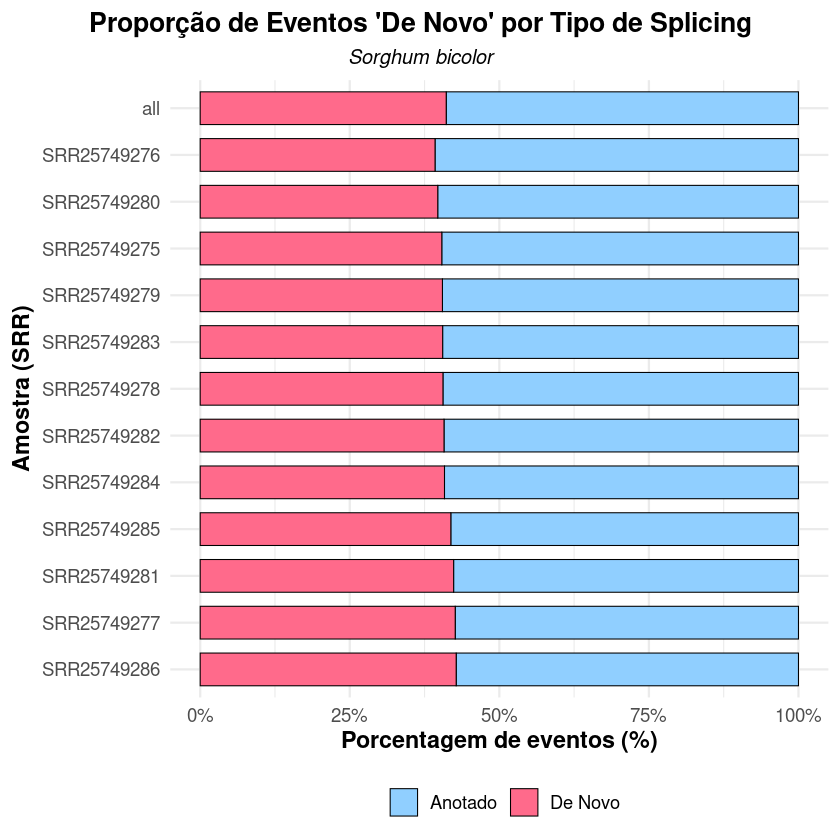

In [178]:
title = "Proportion of 'De Novo' Events by Splicing Type"
subtitle = species
x = "Sample (SRR)"  
y = "Percentage of Events (%)"
legend_title = ""

title = "Proporção de Eventos 'De Novo' por Tipo de Splicing"
subtitle = species
x = "Amostra (SRR)"
y = "Porcentagem de eventos (%)"
legend_title = ""

# Plotting the data - Bar plot per srr id
denovo_sra_id = ggplot(data = de_novo_per_sra_id, aes(
    x = sra_id, 
    y = count, 
    fill = de_novo)) +
  geom_col(position = "fill", width = 0.7, color = "black", linewidth = 0.3) +
  scale_y_continuous(labels = percent_format()) +
  coord_flip() +

  # Formatting
  labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y,
    fill = legend_title
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "bottom",
        plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11),
        axis.title = element_text(face = "bold", size = 14),
        plot.title.position = "plot",
        plot.caption.position = "plot"
) +
  scale_fill_manual(values = c("Anotado"="#90CFFF", "De Novo"="#FF6A8B"))

denovo_sra_id

ggsave(denovo_sra_id, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/proporcao_de_novo_por_srr_id_Sbicolor.svg", 
       width = 10, height = 6)

In [128]:
athaliana_sample_info

athaliana_event_summary_anotado = athaliana_sample_info %>%
    count(de_novo, name = "count") %>%
    mutate(percentage = count / sum(count) * 100,
    de_novo = if_else(de_novo == "True", "De Novo", "Anotado")) %>%
    mutate(species = "Arabidopsis thaliana") 

zmays_event_summary_anotado = zeamays_sample_info %>%
    count(de_novo, name = "count") %>%
    mutate(percentage = count / sum(count) * 100,
    de_novo = if_else(de_novo == "True", "De Novo", "Anotado")) %>%
    mutate(species = "Zea mays")

osativa_event_summary_anotado = oryzasativa_sample_info %>%
    count(de_novo, name = "count") %>%
    mutate(percentage = count / sum(count) * 100,
    de_novo = if_else(de_novo == "True", "De Novo", "Anotado")) %>%
    mutate(species = "Oryza sativa")

sorghumbicolor_event_summary_anotado = sorghumbicolor_sample_info %>%
    count(de_novo, name = "count") %>%
    mutate(percentage = count / sum(count) * 100,
    de_novo = if_else(de_novo == "True", "De Novo", "Anotado")) %>%
    mutate(species = "Sorghum bicolor")

# Combine all event summaries into a single data frame
species_event_summary_anotado <- bind_rows(
    athaliana_event_summary_anotado,
    zmays_event_summary_anotado,
    osativa_event_summary_anotado,
    sorghumbicolor_event_summary_anotado
)

ordered_event_types <- species_event_summary_anotado %>%
  filter(de_novo == "De Novo") %>%
  arrange(desc(percentage)) %>%
  pull(species) %>%
  unique()

species_event_summary_anotado <- species_event_summary_anotado %>%
  mutate(species = factor(species, levels = ordered_event_types))

species_event_summary_anotado

id,event_id,de_novo,mean_psi_majiq,psi_sgseq,sra_id,majiq,sgseq,species
<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<int>,<int>,<chr>
247511,"AT3G52260_Chr3:19383916,19384000-19384456,19384525_-_A5SS",False,0.80520,0,SRR27051148,1,0,Arabidopsis thaliana
247512,"AT3G52260_Chr3:19383916,19384000-19384460,19384525_-_A5SS",False,0.18730,0,SRR27051148,1,0,Arabidopsis thaliana
247513,"AT3G52560_Chr3:19494903,19495028-19495266,19495408_-_A5SS",False,0.22910,0,SRR27051148,1,0,Arabidopsis thaliana
247514,"AT3G52560_Chr3:19494903,19495028-19495269,19495408_-_A5SS",False,0.77070,0,SRR27051148,1,0,Arabidopsis thaliana
247515,"AT2G06005_Chr2:2332819,2332910-2332991,2333095_+_A5SS",True,0.73940,0,SRR27051148,1,0,Arabidopsis thaliana
247516,"AT2G06005_Chr2:2332819,2332906-2332991,2333095_+_A5SS",False,0.23810,0,SRR27051148,1,0,Arabidopsis thaliana
247517,"AT1G03000_Chr1:689532,689813-689981,690173_-_A5SS",True,0.28600,0,SRR27051148,1,0,Arabidopsis thaliana
247518,"AT1G03000_Chr1:689532,689813-689985,690173_-_A5SS",False,0.71400,0,SRR27051148,1,0,Arabidopsis thaliana
247519,"AT2G06025_Chr2:2351395,2351548-2351672,2351748_+_A5SS",False,0.89060,0,SRR27051148,1,0,Arabidopsis thaliana


de_novo,count,percentage,species
<chr>,<int>,<dbl>,<fct>
Anotado,344624,81.92946,Arabidopsis thaliana
De Novo,76011,18.07054,Arabidopsis thaliana
Anotado,142291,57.48899,Zea mays
De Novo,105219,42.51101,Zea mays
Anotado,255793,57.48325,Oryza sativa
De Novo,189194,42.51675,Oryza sativa
Anotado,187097,58.87923,Sorghum bicolor
De Novo,130667,41.12077,Sorghum bicolor


In [129]:
species_event_summary_anotado <- sample_info %>%
  # 1. Filtra pelas espécies de interesse (se necessário)
  filter(species %in% c("Arabidopsis thaliana", "Oryza sativa", "Zea mays", "Sorghum bicolor")) %>%
  
  # 2. Agrupa por espécie E pelo status de_novo
  group_by(species, de_novo) %>%
  
  # 3. Conta os event_ids ÚNICOS em cada grupo
  summarise(count = n_distinct(event_id), .groups = "drop") %>%
  
  # 4. Reagrupa apenas por espécie para calcular a porcentagem correta
  group_by(species) %>%
  
  # 5. Calcula a porcentagem baseada no novo total de eventos únicos por espécie
  mutate(percentage = count / sum(count) * 100) %>%
  
  # 6. Desagrupa para segurança
  ungroup() %>%
  
  # 7. Renomeia a coluna de_novo para ficar mais bonita no gráfico
  mutate(de_novo = if_else(de_novo == "True", "De Novo", "Anotado"))

# O código para reordenar as espécies para o gráfico continua o mesmo, se você precisar
ordered_species <- species_event_summary_anotado %>%
  filter(de_novo == "De Novo") %>%
  arrange(desc(percentage)) %>%
  pull(species) %>%
  unique()

species_event_summary_anotado <- species_event_summary_anotado %>%
  mutate(species = factor(species, levels = ordered_species))

  species_event_summary_anotado

species,de_novo,count,percentage
<fct>,<chr>,<int>,<dbl>
Arabidopsis thaliana,Anotado,30670,73.10562
Arabidopsis thaliana,De Novo,11283,26.89438
Oryza sativa,Anotado,53438,52.76837
Oryza sativa,De Novo,47831,47.23163
Sorghum bicolor,Anotado,41512,55.92725
Sorghum bicolor,De Novo,32713,44.07275
Zea mays,Anotado,41311,52.61207
Zea mays,De Novo,37209,47.38793


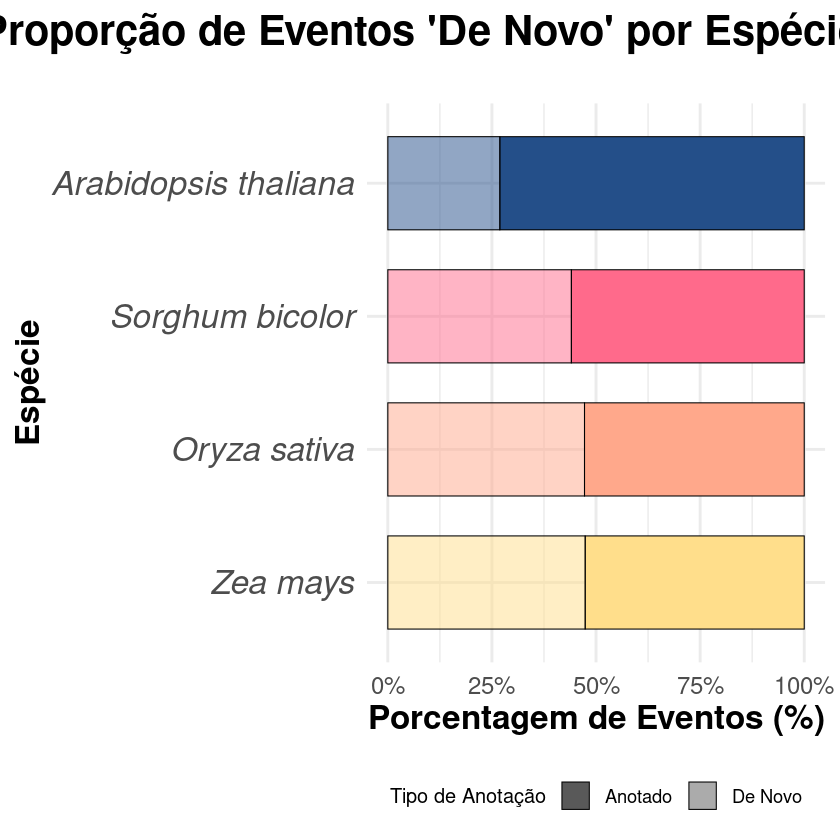

In [132]:
title = "Proportion of 'De Novo' Events by Species"
subtitle = ''
x = "Species"
y = "Percentage of Events (%)"
legend_title = "Annotation Type"


title = "Proporção de Eventos 'De Novo' por Espécie"
subtitle = ''
x = "Espécie"
y = "Porcentagem de Eventos (%)"
legend_title = "Tipo de Anotação"

# Plotting the data - Bar plot per srr id
denovo_species = ggplot(data = species_event_summary_anotado, aes(
    x = species, 
    y = count, 
    fill = species,
    alpha = de_novo)) +
  geom_col(position = "fill", width = 0.7, color = "black", linewidth = 0.3) +
  scale_y_continuous(labels = percent_format()) +
  coord_flip() +

  # Formatting
  labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y,
    fill = legend_title,
    alpha = legend_title
  ) +
  theme_minimal(base_size = 18) +
  theme(legend.position = "bottom",
        plot.title = element_text(hjust = 0.5, size = 25, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 11),
        axis.title.x = element_text(face = "bold", size = 20),
        axis.title.y = element_text(face = "bold", size = 20),
        plot.title.position = "plot",
        axis.text.y = element_text(face = "italic", size = 20),
        plot.caption.position = "plot"
) +
  scale_fill_manual(values = species_color_palette, guide = "none") +
  scale_alpha_manual(values = c("Anotado" = 1.0, "De Novo" = 0.5)) 

denovo_species

ggsave(denovo_species, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/proporcao_de_novo_por_especies.svg", 
       width = 14, height = 6)

### Average PSI (Percent Spliced-In)
📎 Análise do valor médio de PSI (Percent Spliced-In), que quantifica o nível de inclusão de um éxon para cada tipo de evento de splicing.

❓ Quais tipos de eventos tendem a ser mais incluídos (PSI alto) versus mais excluídos (PSI baixo)? A regulação da inclusão de éxons varia significativamente entre os diferentes tipos de splicing?

In [57]:
library(tidyr)
psi_geral_summary <- splicing_events_df %>%
    select(event_type, mean_psi_majiq) %>%
    separate_rows(mean_psi_majiq, sep = ";") %>%
    mutate(psi_value = as.numeric(mean_psi_majiq)) %>%
    filter(!is.na(psi_value))

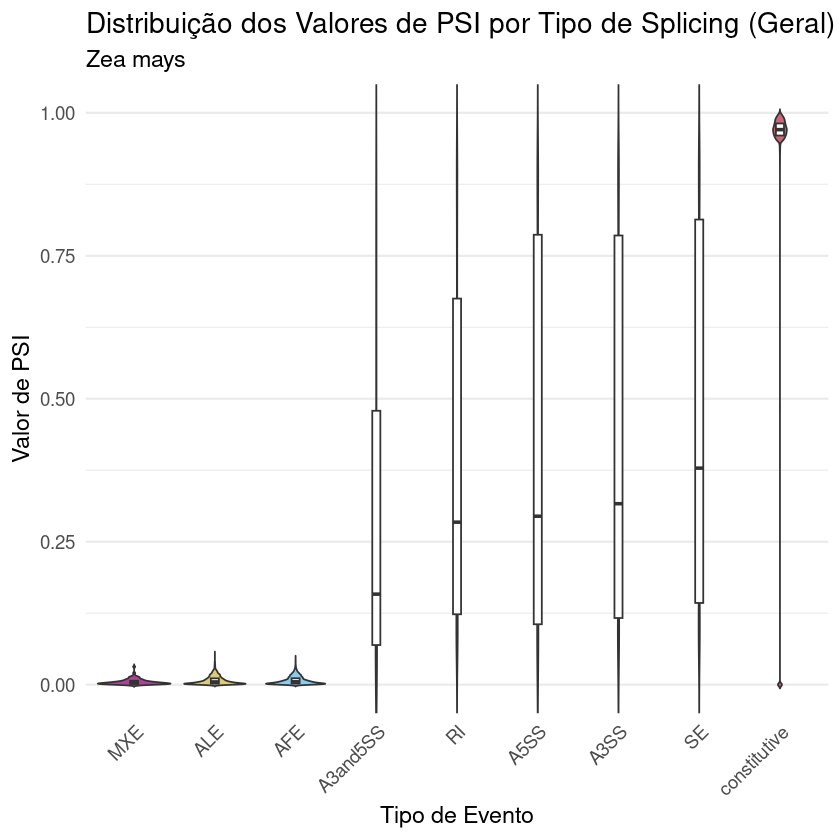

In [146]:
title = "Distribuição dos Valores de PSI por Tipo de Splicing (Geral)"
subtitle = species
x = "Tipo de Evento"
y = "Valor de PSI"
legend_title = ""

# Plotting the data - Violin plor psi
psi_geral_plot_fixed <- ggplot(
    psi_geral_summary, 
    aes(x = reorder(event_type, psi_value, FUN = median), y = psi_value, fill = event_type)
  ) +
  geom_violin(trim = FALSE, show.legend = FALSE) +
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA, coef = 0, show.legend = FALSE) +
    coord_cartesian(ylim = c(0, 1)) +
    
  # Formatting
  labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.x = element_blank()
  ) +
  scale_fill_manual(values = event_color_palette) 

psi_geral_plot_fixed

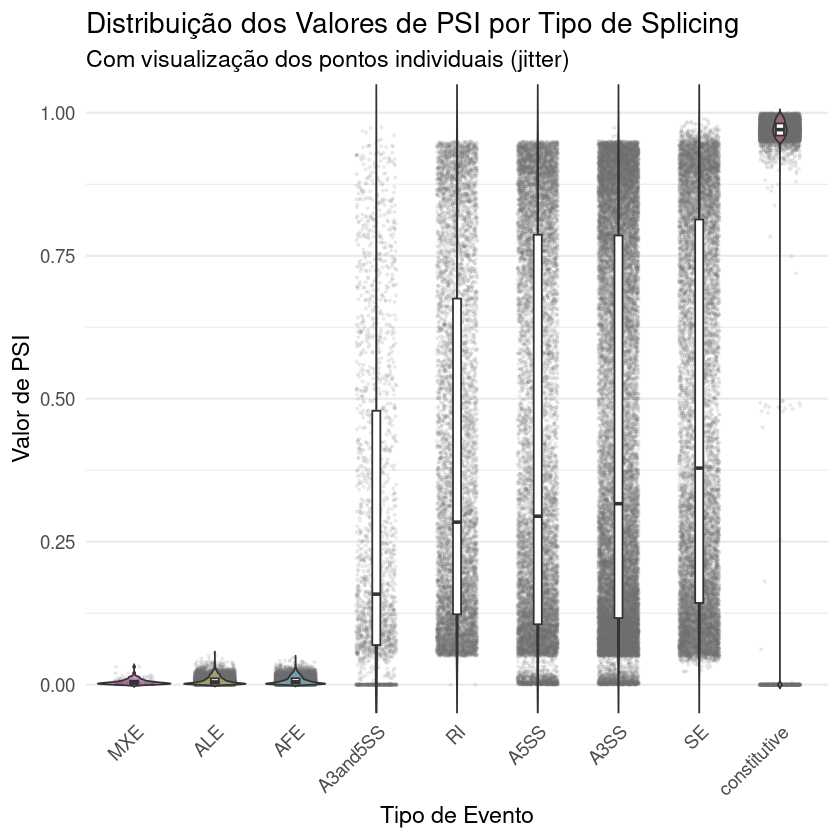

In [ ]:
psi_plot_with_jitter <- ggplot(
    psi_geral_summary, 
    aes(x = reorder(event_type, psi_value, FUN = median), y = psi_value, fill = event_type)
  ) +
  
  geom_jitter(width = 0.25, alpha = 0.1, size = 0.5, show.legend = FALSE, color = "#6e6e6e") +
  
  geom_violin(trim = FALSE, show.legend = FALSE, alpha = 0.5) + # Adicionei alpha para ver os pontos através dele
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA, coef = 0, show.legend = FALSE) +
  
  coord_cartesian(ylim = c(0, 1)) +

  labs(
    title = "Distribuição dos Valores de PSI por Tipo de Splicing",
    subtitle = "Com visualização dos pontos individuais (jitter)",
    x = "Tipo de Evento",
    y = "Valor de PSI"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.x = element_blank()
  ) +
  scale_fill_manual(values = event_color_palette)

psi_plot_with_jitter

In [58]:
psi_geral_summary <- splicing_events_df %>%
  select(event_type, mean_psi_majiq) %>%
  separate_rows(mean_psi_majiq, sep = ";") %>%
  mutate(psi_value = as.numeric(mean_psi_majiq)) %>%
  filter(!is.na(psi_value))

psi_medians <- psi_geral_summary %>%
  group_by(event_type) %>%
  summarise(median_psi = median(psi_value))

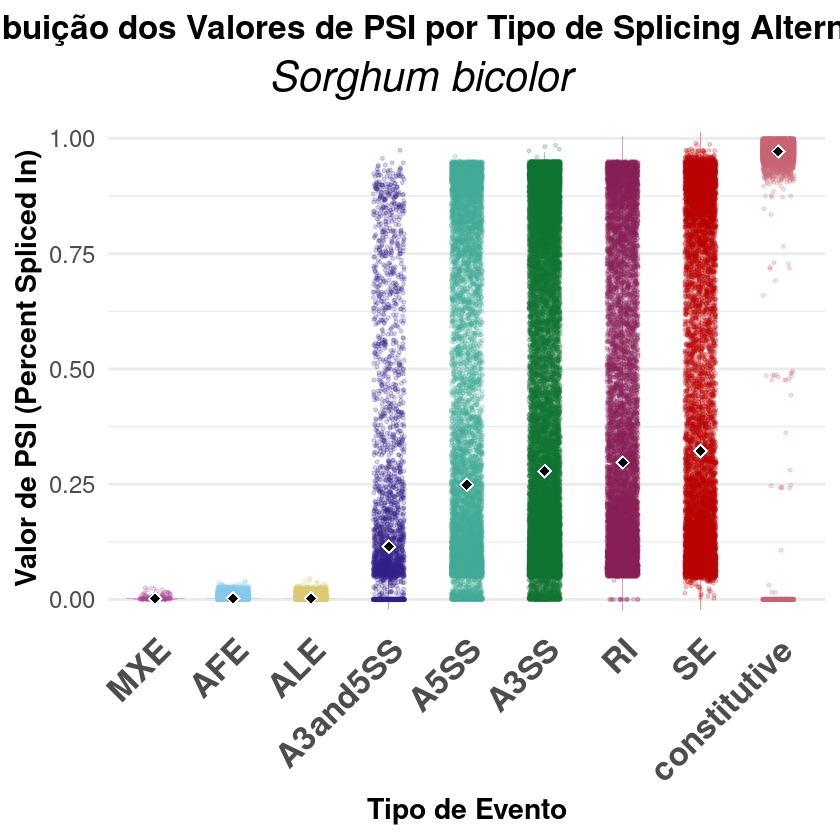

In [59]:
title = "Distribution of PSI Values by Alternative Splicing Type"
subtitle = species
x = "Event Type"
y = "PSI Value (Percent Spliced-In)"
legend_title = ""

title = "Distribuição dos Valores de PSI por Tipo de Splicing Alternativo"
subtitle = species
x = "Tipo de Evento"
y = "Valor de PSI (Percent Spliced In)"
legend_title = ""

# Plotting the data - Raincloud/jitter plot with median points
psi_final_plot <- ggplot(
    psi_geral_summary, 
    aes(x = reorder(event_type, psi_value, FUN = median), y = psi_value)
  ) +
  geom_jitter(
    aes(color = event_type),
    width = 0.2, 
    alpha = 0.2, 
    size = 0.8,
    show.legend = FALSE
  ) +
    geom_violin(
    aes(fill = event_type),
    trim = FALSE, 
    alpha = 0.4,
    show.legend = FALSE,
    color = NA 
  ) +
  geom_point(
    data = psi_medians,
    aes(x = event_type, y = median_psi),
    shape = 18, 
    color = "white",
    size = 4
  ) +
  geom_point(
    data = psi_medians,
    aes(x = event_type, y = median_psi),
    shape = 18,
    color = "black",
    size = 2.5
  ) +
    coord_cartesian(ylim = c(0, 1)) +
  scale_color_manual(values = event_color_palette) +
  scale_fill_manual(values = event_color_palette) +
  
  labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 20),
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold", size = 20),
    panel.grid.major.x = element_blank(),
    plot.title.position = "plot",
    plot.caption.position = "plot",
    plot.subtitle = element_text(hjust = 0.5, size = 25, face = "italic"),
    axis.title = element_text(face = "bold", size = 17)
  )

psi_final_plot

ggsave(psi_final_plot, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/distribuicao_valores_psi_por_tipo_splicing_Sbicolor.png", 
       width = 10, height = 6)

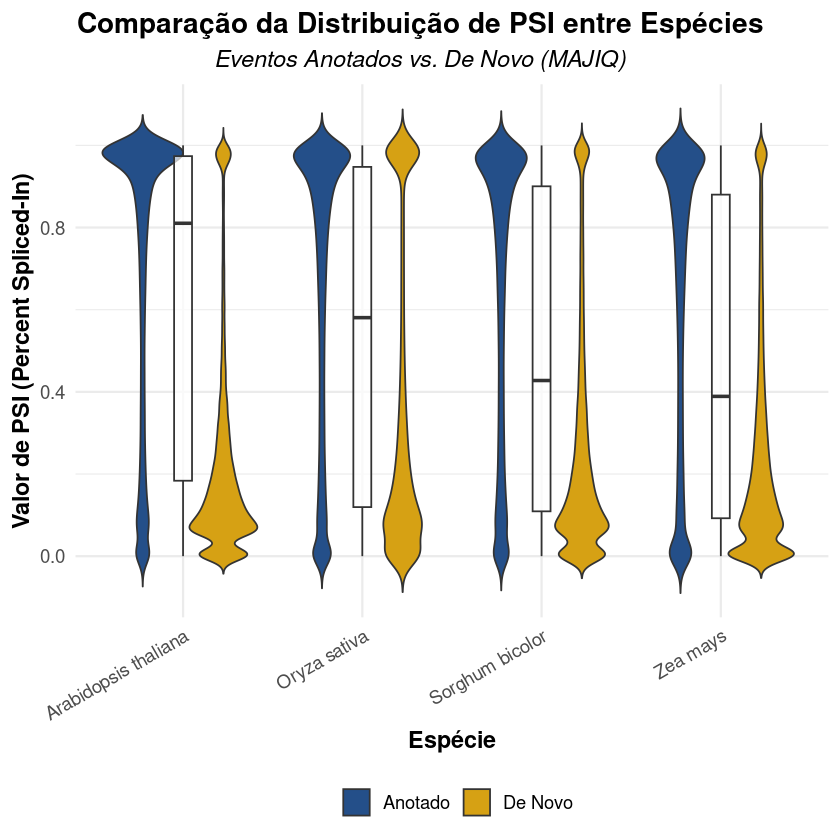

In [59]:

title = "Distribution of PSI Values by Alternative Splicing Type"
subtitle = species
x = "Event Type"
y = "PSI Value (Percent Spliced-In)"
legend_title = ""

title = "Distribuição dos Valores de PSI por Tipo de Splicing Alternativo"
subtitle = species
x = "Tipo de Evento"
y = "Valor de PSI (Percent Spliced In)"
legend_title = ""

psi_distribution_data <- sample_info %>%
  mutate(mean_psi_majiq = suppressWarnings(as.numeric(mean_psi_majiq))) %>%
  filter(!is.na(mean_psi_majiq)) %>%
  mutate(status = if_else(de_novo == "True", "De Novo", "Anotado"))

psi_comparison_plot <- ggplot(
    psi_distribution_data, 
    aes(x = species, y = mean_psi_majiq, fill = status)
  ) +
  
  geom_violin(
    position = position_dodge(width = 0.9), 
    trim = FALSE, 
  ) +
    geom_boxplot(
    width = 0.1, 
    fill = "white", 
    alpha = 0.7,
    position = position_dodge(width = 0.9)
  ) +
  scale_fill_manual(values = c("Anotado" = "#244f89", "De Novo" = "#d6a114")) +
  # scale_fill_manual(values = c("Anotado" = "#1f78b4", "De Novo" = "#e31a1c")) +
  
  labs(
    title = "Comparação da Distribuição de PSI entre Espécies",
    subtitle = "Eventos Anotados vs. De Novo (MAJIQ)",
    x = "Espécie",
    y = "Valor de PSI (Percent Spliced-In)",
    fill = ""
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5, face = "italic"),
    axis.title = element_text(face = "bold"),
    axis.title.x = element_text(face = "bold", size = 14),
    axis.title.y = element_text(face = "bold", size = 14),
    legend.position = "bottom",
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 11),
    plot.title.position = "plot",
    plot.caption.position = "plot",
    axis.text.x = element_text(angle = 30, hjust = 1)  
  )

# Exibe o gráfico
print(psi_comparison_plot)

ggsave(psi_comparison_plot, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/comparacao_distribuicao_psi_entre_especies.png", 
       width = 10, height = 6)

### Distribuição Cromossômica
📎 Visualização da distribuição e frequência dos diferentes tipos de eventos de splicing ao longo dos cromossomos.

❓ Existem "hotspots" de splicing no genoma? Certos tipos de eventos de splicing são mais frequentes em cromossomos específicos?

In [ ]:
library(forcats)
library(stringr)

events_sem_scaffolds <- athaliana_splicing_events %>%
  filter(!str_detect(seqid, regex("scaffold", ignore_case = TRUE)))

chr_order <- events_sem_scaffolds %>%
  mutate(chr_num = as.numeric(str_extract(seqid, "\\d+"))) %>%
  distinct(seqid, chr_num) %>%
  arrange(chr_num) %>%
  pull(seqid)

heatmap_data <- events_sem_scaffolds %>%
  mutate(seqid = factor(seqid, levels = chr_order)) %>%
  mutate(pos_bin = start %/% 5000000) %>%
  count(seqid, pos_bin, name = "event_count")

head(heatmap_data)


seqid,pos_bin,event_count
<fct>,<dbl>,<int>
1,0,384
1,1,325
1,2,409
1,3,344
1,4,268
1,5,242


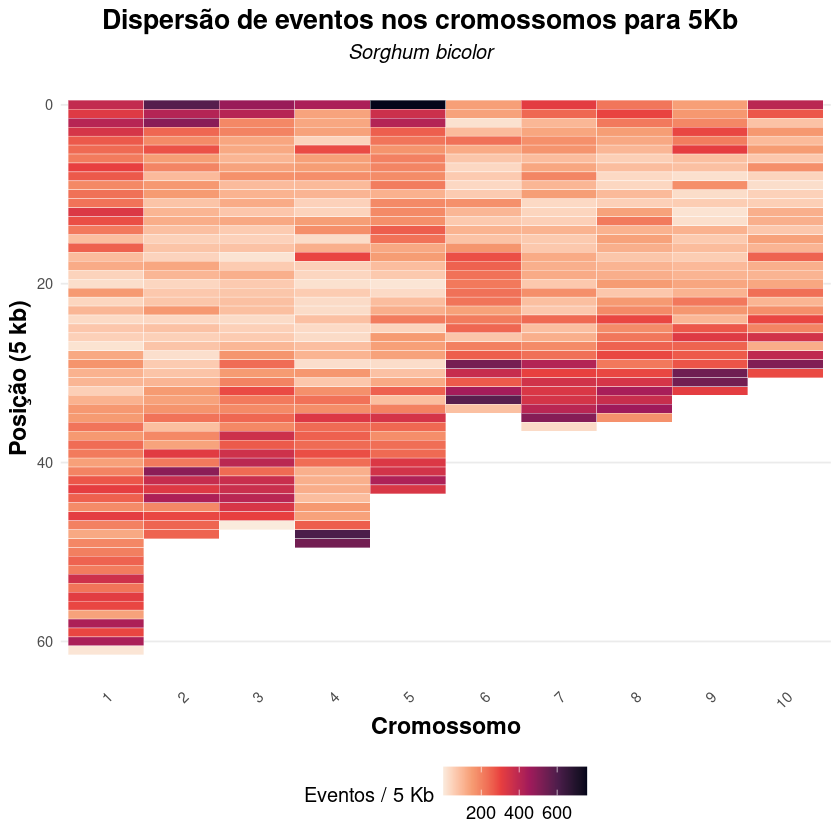

In [181]:
title = "Dispersal of events on chromosomes for 5Kb"
subtitle = species
x = "cromossome"
y = "Position (5 kb)"
legend_title = "Events / 5 Kb"

title = "Dispersão de eventos nos cromossomos para 5Kb"
subtitle = species
x = "Cromossomo"
y = "Posição (5 kb)"
legend_title = "Eventos / 5 Kb"


# Plotting the data - Heatmap of Splicing Events

heatmapp = ggplot(heatmap_data, aes(x = seqid, y = pos_bin, fill = event_count)) +
  geom_tile(color = "white", size = 0.1) +
  scale_fill_viridis_c(option = "rocket", direction = -1) +
  scale_y_reverse() +
  labs(
    title = title,
    subtitle = subtitle,
    x = x,
    y = y,
    fill = legend_title
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 11),
    axis.title = element_text(face = "bold", size = 14),
    plot.title.position = "plot",
    plot.caption.position = "plot",
    panel.grid.major.x = element_blank(),
    panel.grid.minor.y = element_blank(),
    legend.position = "bottom"
  )

heatmapp

ggsave(heatmapp, filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/dispersao_eventos_cromossomos_5Kb_Sbicolor.svg", width = 10, height = 6)

TIPO_DE_SPLICING,Grupo_Tecido,Contagem,Tipo_Evento,Proporcao,Posicao_Label,Label
<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<chr>
EX,Embryo,1688182,SE,0.2358082,0.1179041,23.6%
EX,Flower,1069705,SE,0.2398172,0.1199086,24%
EX,Leaf,1805150,SE,0.2361347,0.1180673,23.6%
EX,Root,803119,SE,0.2368175,0.1184088,23.7%
EX,Seed,851687,SE,0.2358819,0.1179410,23.6%
EX,Silique,680591,SE,0.2360189,0.1180095,23.6%
EX,Stem,238063,SE,0.2383784,0.1191892,23.8%
INT,Embryo,2015623,RI,0.2815458,0.3765811,28.2%
INT,Flower,1275552,RI,0.2859661,0.3828003,28.6%


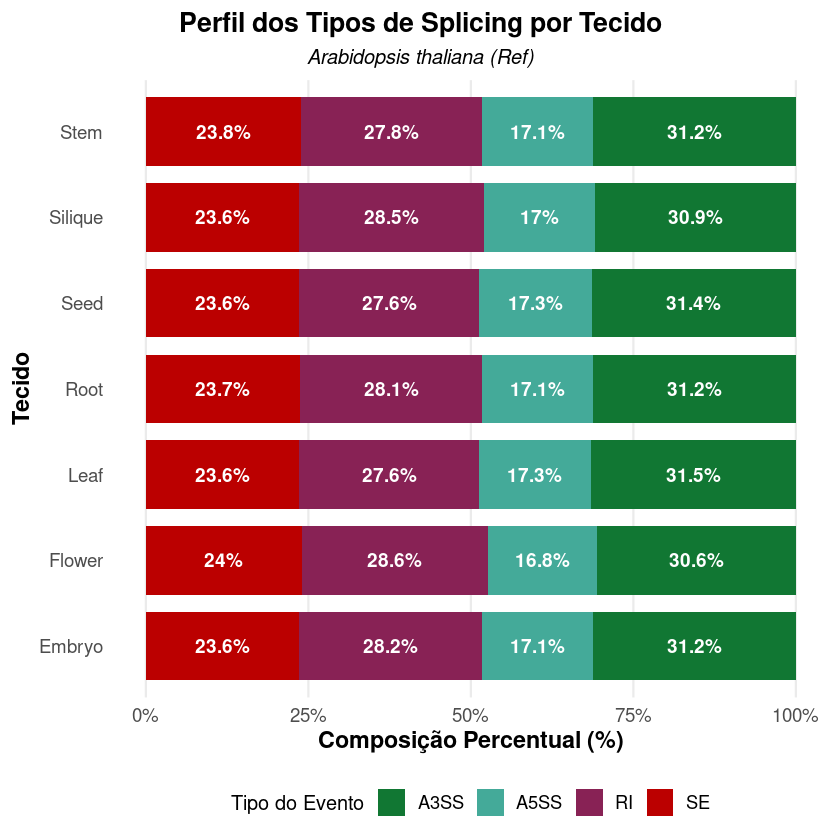

In [76]:

library("tidyr")

dados_texto <- "
TIPO_DE_SPLICING  Embryo  Flower  Leaf  Root  Seed  Silique Stem
ALTA  2230655 1366322 2409596 1057424 1135179 892339  311914
ALTD  1224671 748922  1320382 578499  625515  489712  170888
EX  1688182 1069705 1805150 803119  851687  680591  238063
INT 2015623 1275552 2109451 952257  998269  820987  277812
"
dados_largos <- read.table(text = dados_texto, header = TRUE)

dados_longos <- dados_largos %>%
  pivot_longer(
    cols = -TIPO_DE_SPLICING, 
    names_to = "Grupo_Tecido", 
    values_to = "Contagem"
  ) %>%
  mutate(Tipo_Evento = case_when(
    TIPO_DE_SPLICING == "ALTA"  ~ "A3SS",
    TIPO_DE_SPLICING == "ALTD"  ~ "A5SS",
    TIPO_DE_SPLICING == "EX"    ~ "SE",
    TIPO_DE_SPLICING == "INT"   ~ "RI"
  ))

dados_com_percentuais <- dados_longos %>%
  group_by(Grupo_Tecido) %>%
  arrange(desc(Tipo_Evento)) %>%
  mutate(
    Proporcao = Contagem / sum(Contagem),
    Posicao_Label = cumsum(Proporcao) - Proporcao / 2,
    Label = if_else(Proporcao > 0.03, paste0(round(Proporcao * 100, 1), "%"), "")
  )

dados_com_percentuais

stacked_bar_chart <- ggplot(dados_com_percentuais, aes(x = Grupo_Tecido, y = Proporcao, fill = Tipo_Evento)) +
  geom_col(width = 0.8) +
  geom_text(aes(y = Posicao_Label, label = Label), color = "white", size = 4, fontface = "bold") +
  coord_flip() +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = event_color_palette) +
  labs(
    title = "Perfil dos Tipos de Splicing por Tecido",
    subtitle = "Arabidopsis thaliana (Ref)",
    x = "Tecido",
    y = "Composição Percentual (%)",
    fill = "Tipo do Evento"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 11),
    axis.title = element_text(face = "bold", size = 14),
    legend.position = "bottom",
    plot.title.position = "plot",
    panel.grid.major.y = element_blank(),
    panel.grid.minor.x = element_blank()
  ) +
  guides(fill = guide_legend(nrow = 1))

print(stacked_bar_chart)

ggsave(stacked_bar_chart, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/perfil_tipos_splicing_grupo_tecido.svg",
       width = 10, height = 6)

In [98]:
combined_event_summary_3 = combined_event_summary_2 %>%
  # 1. Filtra para remover a linha com "CS"
  filter(event_type %in% c("SE", "RI", "A3SS", "A5SS")) %>%
  
  # 2. Agrupa os dados por espécie
  group_by(species) %>%
  
  # 3. Recalcula a porcentagem baseada no novo total de cada espécie
  mutate(percentage = (percentage / sum(percentage)) * 100) %>%
  
  # 4. Desagrupa para futuras operações
  ungroup()

dados_alternativos_apenas <- dados_publicados %>%
  # 1. Filtra para remover a linha com "CS"
  filter(event_type != "constitutive") %>%
  
  # 2. Agrupa os dados por espécie
  group_by(species) %>%
  
  # 3. Recalcula a porcentagem baseada no novo total de cada espécie
  mutate(percentage = (percentage / sum(percentage)) * 100) %>%
  
  # 4. Desagrupa para futuras operações
  ungroup() %>%

  # 5. Padroniza os nomes dos eventos (opcional, mas recomendado)
  mutate(event_type = recode(event_type,
                            "INT" = "RI",
                            "EX" = "SE",
                            "ALTA" = "A3SS",
                            "ALTD" = "A5SS"))
dados_alternativos_apenas
dados_com_percentuais

meus_dados_proc <- bind_rows(combined_event_summary_3 %>%
  filter(species == "Arabidopsis thaliana") %>%
  mutate(Fonte = "Arabidopsis thaliana (SpliceScape)") %>%
  select(Fonte, event_type = event_type, Porcentagem = percentage),

  combined_event_summary_3 %>%
  filter(species == "Oryza sativa") %>%
  mutate(Fonte = "Oryza sativa (SpliceScape)") %>%
  select(Fonte, event_type = event_type, Porcentagem = percentage), 
  
  combined_event_summary_3 %>%
  filter(species == "Sorghum bicolor") %>%
  mutate(Fonte = "Sorghum bicolor (SpliceScape)") %>%
  select(Fonte, event_type = event_type, Porcentagem = percentage),
  
  combined_event_summary_3 %>%
  filter(species == "Zea mays") %>%
  mutate(Fonte = "Zea mays (SpliceScape)") %>%
  select(Fonte, event_type = event_type, Porcentagem = percentage))

# Tabela 2: Dados publicados de referência
# Mapa para traduzir os nomes dos eventos
event_map_publicados <- c("RI" = "RI", "SE" = "SE", "A3SS" = "A3SS", "A5SS" = "A5SS")

dados_publicados_proc <- dados_alternativos_apenas %>%
  filter(species == "Arabidopsis thaliana (Ref.)") %>%
  mutate(Fonte = "Arabidopsis thaliana (Ref.)",
         event_type = recode(event_type, !!!event_map_publicados)) %>%
  select(Fonte, event_type, Porcentagem = percentage)

# Tabela 3: Dados de tecido (Folha)
event_map_tecido <- c("EX" = "SE", "INT" = "RI", "ALTD" = "A5SS", "ALTA" = "A3SS")

dados_tecido_proc <- dados_com_percentuais %>%
  filter(Grupo_Tecido == "Leaf") %>%
  mutate(Fonte = "Arabidopsis thaliana Leaf (Ref.)",
         event_type = recode(TIPO_DE_SPLICING, !!!event_map_tecido),
         Porcentagem = Proporcao * 100) %>% # Converte proporção para porcentagem
  select(Fonte, event_type, Porcentagem)

# --- 3. Combinar todos os dataframes em uma única tabela ---
tabela_final_unificada <- bind_rows(
  dados_publicados_proc,
  dados_tecido_proc, 
  meus_dados_proc
)


tabela_final_unificada <- tabela_final_unificada %>%
  mutate(Porcentagem = Porcentagem / 100)

tabela_final_unificada <- tabela_final_unificada %>%
  mutate(Fonte = factor(Fonte, levels = c(
    "Arabidopsis thaliana (Ref.)",
    "Arabidopsis thaliana Leaf (Ref.)",
    "Arabidopsis thaliana (SpliceScape)",
    "Oryza sativa (SpliceScape)",
    "Sorghum bicolor (SpliceScape)",
    "Zea mays (SpliceScape)"
  )))

tabela_final_unificada


species,event_type,percentage
<chr>,<chr>,<dbl>
Human - HG18,RI,13.333333
Human - HG18,SE,63.456790
Human - HG18,A3SS,13.827160
Human - HG18,A5SS,9.382716
Human - HG38,RI,23.062731
Human - HG38,SE,56.088561
Human - HG38,A3SS,13.099631
Human - HG38,A5SS,7.749077
Arabidopsis thaliana (Ref.),RI,34.204793


TIPO_DE_SPLICING,Grupo_Tecido,Contagem,Tipo_Evento,Proporcao,Posicao_Label,Label
<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<chr>
EX,Embryo,1688182,SE,0.2358082,0.1179041,23.6%
EX,Flower,1069705,SE,0.2398172,0.1199086,24%
EX,Leaf,1805150,SE,0.2361347,0.1180673,23.6%
EX,Root,803119,SE,0.2368175,0.1184088,23.7%
EX,Seed,851687,SE,0.2358819,0.1179410,23.6%
EX,Silique,680591,SE,0.2360189,0.1180095,23.6%
EX,Stem,238063,SE,0.2383784,0.1191892,23.8%
INT,Embryo,2015623,RI,0.2815458,0.3765811,28.2%
INT,Flower,1275552,RI,0.2859661,0.3828003,28.6%


Adding missing grouping variables: `Grupo_Tecido`


Fonte,event_type,Porcentagem,Grupo_Tecido
<fct>,<chr>,<dbl>,<chr>
Arabidopsis thaliana (Ref.),RI,0.34204793,NA
Arabidopsis thaliana (Ref.),SE,0.27559913,NA
Arabidopsis thaliana (Ref.),A3SS,0.12962963,NA
Arabidopsis thaliana (Ref.),A5SS,0.25272331,NA
Arabidopsis thaliana Leaf (Ref.),SE,0.23613465,Leaf
Arabidopsis thaliana Leaf (Ref.),RI,0.27594077,Leaf
Arabidopsis thaliana Leaf (Ref.),A5SS,0.17272135,Leaf
Arabidopsis thaliana Leaf (Ref.),A3SS,0.31520323,Leaf
Arabidopsis thaliana (SpliceScape),A3SS,0.50932967,NA


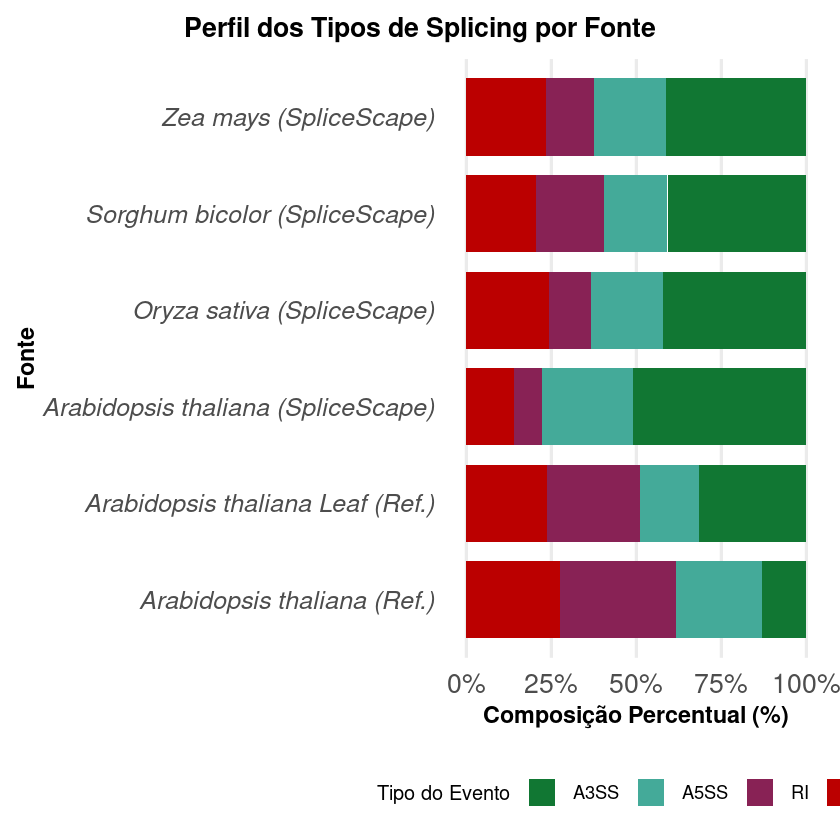

In [100]:


stacked_bar_chart2 <- ggplot(tabela_final_unificada, aes(x = Fonte, y = Porcentagem, fill = event_type)) +
  geom_col(width = 0.8) +
  coord_flip() +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = event_color_palette) +
  labs(
    title = "Perfil dos Tipos de Splicing por Fonte",
    x = "Fonte",
    y = "Composição Percentual (%)",
    fill = "Tipo do Evento"
  ) +
  theme_minimal(base_size = 20) +
  theme(
    plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 11),
    axis.title = element_text(face = "bold", size = 14),
    axis.text.y = element_text(face = "italic", size = 15),
    legend.position = "bottom",
    plot.title.position = "plot",
    panel.grid.major.y = element_blank(),
    panel.grid.minor.x = element_blank()
  ) +
  guides(fill = guide_legend(nrow = 1))

print(stacked_bar_chart2)

ggsave(stacked_bar_chart2, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/perfilo.png",
       width = 10, height = 6)

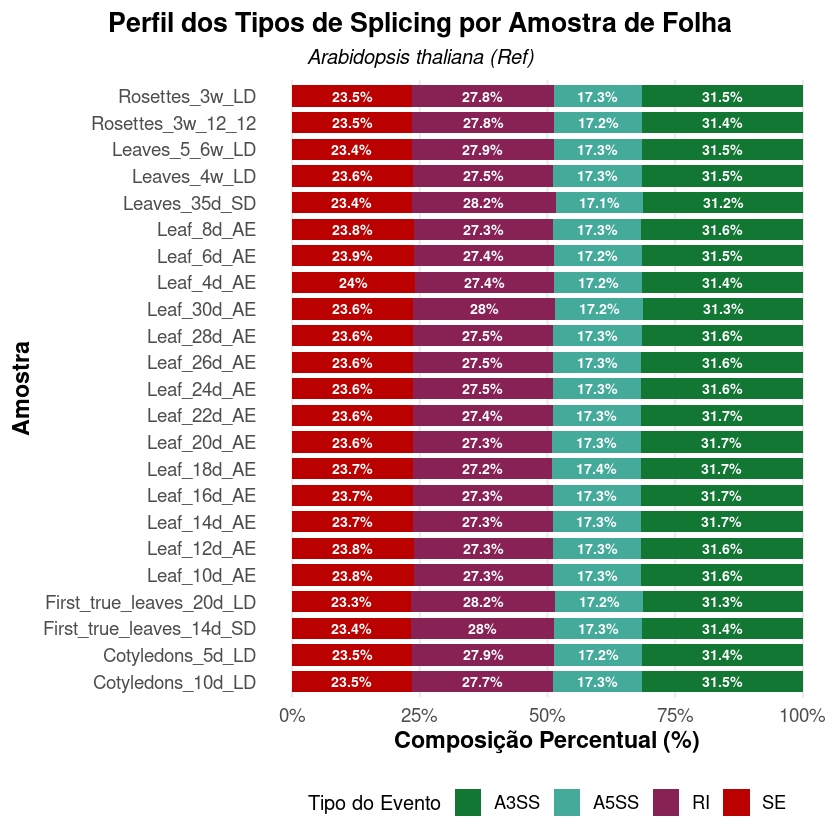

In [183]:


dados_texto <- "
TIPO_DE_SPLICING	Cotyledons_10d_LD	Cotyledons_5d_LD	First_true_leaves_14d_SD	First_true_leaves_20d_LD	Leaf_10d_AE	Leaf_12d_AE	Leaf_14d_AE	Leaf_16d_AE	Leaf_18d_AE	Leaf_20d_AE	Leaf_22d_AE	Leaf_24d_AE	Leaf_26d_AE	Leaf_28d_AE	Leaf_30d_AE	Leaf_4d_AE	Leaf_6d_AE	Leaf_8d_AE	Leaves_35d_SD	Leaves_4w_LD	Leaves_5_6w_LD	Rosettes_3w_12_12	Rosettes_3w_LD
ALTA	107806	107967	108835	111289	101422	101674	101989	102532	101897	103035	103129	104080	104249	103925	101319	99003	101751	100735	111392	107434	109321	107717	107095
ALTD	59137	59102	59787	61119	55528	55772	55808	56041	55822	56348	56485	57015	57159	56975	55632	54152	55639	55146	61059	58927	60062	58984	58683
EX	80202	80621	81002	83048	76481	76516	76452	76770	76174	76774	77042	77606	77845	77609	76439	75513	77067	76063	83601	80480	81310	80603	79932
INT	94811	95610	96887	100235	87598	87770	87836	88372	87404	88675	89175	90321	90750	90539	90716	86248	88596	86983	100593	93820	96791	95304	94417
"

dados_largos <- read.table(text = dados_texto, header = TRUE, check.names = FALSE)

dados_longos <- dados_largos %>%
  pivot_longer(
    cols = -TIPO_DE_SPLICING, 
    names_to = "Grupo_Tecido", 
    values_to = "Contagem"
  ) %>%
  mutate(Tipo_Evento = case_when(
    TIPO_DE_SPLICING == "ALTA"  ~ "A3SS",
    TIPO_DE_SPLICING == "ALTD"  ~ "A5SS",
    TIPO_DE_SPLICING == "EX"    ~ "SE",
    TIPO_DE_SPLICING == "INT"   ~ "RI"
  ))

dados_com_percentuais <- dados_longos %>%
  group_by(Grupo_Tecido) %>%
  arrange(desc(Tipo_Evento)) %>%
  mutate(
    Proporcao = Contagem / sum(Contagem),
    Posicao_Label = cumsum(Proporcao) - Proporcao / 2,
    Label = if_else(Proporcao > 0.03, paste0(round(Proporcao * 100, 1), "%"), "")
  )

stacked_bar_chart <- ggplot(dados_com_percentuais, aes(x = Grupo_Tecido, y = Proporcao, fill = Tipo_Evento)) +
  geom_col(width = 0.8) +
  geom_text(aes(y = Posicao_Label, label = Label), color = "white", size = 3, fontface = "bold") +
  coord_flip() +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = event_color_palette) +
  labs(
    title = "Perfil dos Tipos de Splicing por Amostra de Folha",
    subtitle = "Arabidopsis thaliana (Ref)",
    x = "Amostra",
    y = "Composição Percentual (%)",
    fill = "Tipo do Evento"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5, size = 12, face = "italic"),
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 11),
    axis.title = element_text(face = "bold", size = 14),
    legend.position = "bottom",
    plot.title.position = "plot",
    panel.grid.major.y = element_blank(),
    panel.grid.minor.x = element_blank()
  ) +
  guides(fill = guide_legend(nrow = 1))

print(stacked_bar_chart)

ggsave(stacked_bar_chart, 
       filename = "/home/bia/LandscapeSplicingGrasses/Images/biol_analysis/perfil_tipos_splicing_grupo_tecido_folha.png",
       width = 10, height = 6)